<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 04 - GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Generative Adversarial Networks (GANs)

Extra 3 built generative models that write down a density: a VAE maximises a lower bound on $\log p_\theta(\mathbf{x})$, the ELBO, and its samples come out blurry. A **generative adversarial network** takes a different road. It never writes a density. A **generator** turns random noise into samples, and a **discriminator** learns to tell those samples from real data. Each network is the other's loss function: the generator improves by fooling the discriminator, the discriminator by not being fooled. When it works, the samples are sharp. When it fails, it fails in ways that a likelihood-based model does not: one mode at a time, oscillation, or no signal at all.

In this lab we play the game first with numbers, then with small networks where every quantity can be computed exactly (a 1-D mixture, a 2-D ring of 8 Gaussians), and finally on MNIST images. Every theoretical claim of the slides is checked numerically.

**Contents**

1. Generative modelling: densities and samplers
2. The GAN game with numbers
3. A 1-D GAN from scratch
4. The theory, checked: optimal discriminator, Jensen–Shannon, saturation
5. Two-player dynamics: the bilinear game
6. Mode collapse and the Wasserstein GAN
7. DCGAN on MNIST
8. A conditional GAN: digits on demand
9. Evaluation: FID from scratch
10. Summary and exercises

This lab goes with the slides *Extra 4 · Generative adversarial networks* and uses the same notation. It assumes MLPs, CNNs, backpropagation, the PyTorch training loop and cross-entropy from the course, and autoencoders and VAEs from Extra 3. Everything runs on a CPU: about 4 minutes with 4 threads (4.2 in our run), roughly twice that on a 2-core Colab CPU (sections 7 and 8, the image GANs, take most of it). A GPU is optional; sections 7 to 9 then take seconds.

**Notation**

| Symbol | Meaning |
|---|---|
| $\mathbf{x} \sim p_{\text{data}}$ | a real example and the (unknown) data distribution |
| $\mathbf{z} \sim p_z = \mathcal{N}(\mathbf{0}, \mathbf{I})$ | latent noise, of dimension $d_z$ |
| $G_\theta(\mathbf{z})$, $p_g$ | generator with parameters $\theta$; $p_g$ is the distribution of its samples |
| $D_\phi(\mathbf{x}) \in (0, 1)$ | discriminator: the probability that $\mathbf{x}$ is real; $D^*$ is the optimal one |
| $V(D, G)$ | value function of the game, $\mathbb{E}_{p_{\text{data}}}[\log D(\mathbf{x})] + \mathbb{E}_{p_z}[\log(1 - D(G(\mathbf{z})))]$ |
| $f_w(\mathbf{x}) \in \mathbb{R}$ | WGAN critic (a score, no sigmoid) |
| $\mathrm{KL}$, $\mathrm{JS}$, $W_1$ | Kullback–Leibler, Jensen–Shannon and Wasserstein-1 (earth mover's) distances |
| $m$, $\eta$, $k$ | minibatch size, learning rate, discriminator steps per generator step |
| $\lambda$ | weight of the gradient penalty (WGAN-GP) |
| $\boldsymbol{\mu}_r, \boldsymbol{\Sigma}_r$; $\boldsymbol{\mu}_g, \boldsymbol{\Sigma}_g$ | mean and covariance of the features of real / generated images (FID) |

In [1]:
import time, copy, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from scipy import linalg, stats
from scipy.spatial.distance import jensenshannon
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
np.random.seed(0); torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| CPU threads:", torch.get_num_threads())
T_START = time.time()

device: cpu | torch 2.12.0+cu130 | torchvision 0.27.0+cu130 | CPU threads: 4


## 1. Generative modelling: densities and samplers

We have examples $\mathbf{x}_1, \dots, \mathbf{x}_n$ drawn from an unknown distribution $p_{\text{data}}$. A **generative model** learns $p_{\text{data}}$ well enough to do one or both of two things: **evaluate** a density $p(\mathbf{x})$ (how likely is this image?) and **sample** new $\mathbf{x}$ (show me a new image).

- **Explicit-density models** write $p_\theta(\mathbf{x})$ down and maximise the likelihood. *Autoregressive* models factorise it with the chain rule, $p(\mathbf{x}) = \prod_i p(x_i \mid x_{\lt i})$, exactly (PixelCNN, GPT). *Normalising flows* push noise through an invertible map and get the exact density from the change-of-variables formula. *VAEs* (Extra 3) maximise a lower bound, the ELBO.
- **Implicit models** only give a sampler: $\mathbf{x} = G_\theta(\mathbf{z})$ with $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$. There is no formula for $p_g(\mathbf{x})$. A GAN is one.

Why can "learn to sample" be easier than "learn the density"? A density must integrate to 1, which forces either a special architecture (flows, autoregressive) or a bound (VAE). And natural images sit near a thin, low-dimensional set of pixel space, where a density is huge on the set and zero off it; a likelihood is a hard target there, while a generator from a low-dimensional $\mathbf{z}$ simply lands on the set. The price: without a likelihood we need another training signal (the discriminator, section 2) and other ways to evaluate the model (section 9).

**A generator is a push-forward.** If $\mathbf{z} \sim p_z$, then $\mathbf{x} = G(\mathbf{z})$ has some distribution $p_g$: $G$ pushes the noise distribution forward. In one dimension there is an exact recipe. With $\Phi$ the standard normal CDF and $F$ the data CDF,

$$
G^*(z) = F^{-1}\big(\Phi(z)\big) \quad\Longrightarrow\quad P\big(G^*(z) \le t\big) = P\big(\Phi(z) \le F(t)\big) = F(t),
$$

because $\Phi(z)$ is uniform on $(0, 1)$. So $G^*(z)$ has exactly the distribution $F$. For images no such formula exists; a GAN *learns* $G$ from samples.

Our running example is the mixture $p_{\text{data}} = 0.4\,\mathcal{N}(-2, 0.5^2) + 0.6\,\mathcal{N}(2, 0.5^2)$. Its mean is $0.4 \cdot (-2) + 0.6 \cdot 2 = 0.4$ and its variance $\mathbb{E}[x^2] - 0.4^2 = 0.25 + 4 - 0.16 = 4.09$ (standard deviation 2.022).

mean 0.398 (expected 0.400)   std 2.022 (expected 2.022)
fraction below 0: 0.401 (expected 0.400)
Kolmogorov-Smirnov distance to p_data: 0.0019 (p-value 0.87): consistent with p_data
G* crosses the gap between the modes at z = Phi^-1(0.4) = -0.253; slope there: 420


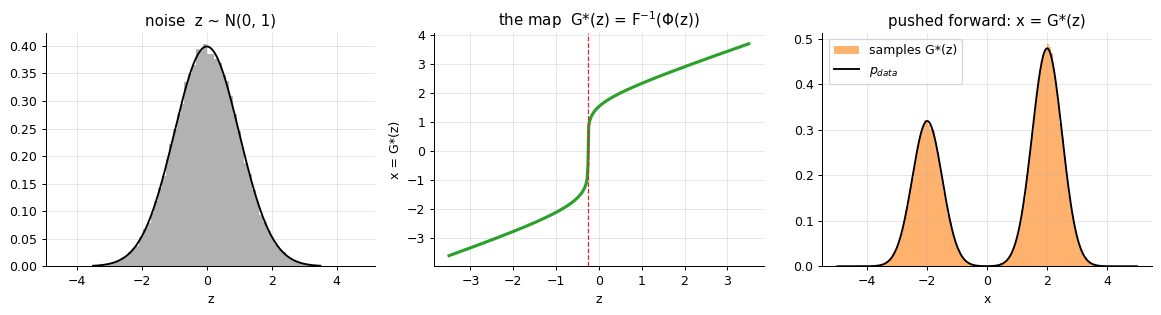

In [2]:
PI, MU, SD = np.array([0.4, 0.6]), np.array([-2.0, 2.0]), np.array([0.5, 0.5])   # weights, means, std devs

def p_data(x):
    # density of the mixture 0.4 N(-2, 0.5^2) + 0.6 N(2, 0.5^2)
    x = np.asarray(x, dtype=float)[..., None]
    return (PI * stats.norm.pdf(x, MU, SD)).sum(-1)

def cdf_data(x):
    x = np.asarray(x, dtype=float)[..., None]
    return (PI * stats.norm.cdf(x, MU, SD)).sum(-1)

PI_T, MU_T, SD_T = (torch.tensor(a, dtype=torch.float32) for a in (PI, MU, SD))
def sample_data(n):
    # n samples of the mixture, as a tensor of shape (n, 1)
    k = torch.multinomial(PI_T, n, replacement=True)
    return (MU_T[k] + SD_T[k] * torch.randn(n)).unsqueeze(1)

# the exact 1-D sampler G*(z) = F^{-1}(Phi(z)); F is inverted numerically on a fine grid
xs_fine = np.linspace(-6, 6, 24001)
F_fine = cdf_data(xs_fine)
def G_star(z):
    return np.interp(stats.norm.cdf(z), F_fine, xs_fine)

z = np.random.default_rng(0).standard_normal(100_000)
x_star = G_star(z)
ks = stats.kstest(x_star, cdf_data)
print(f"mean {x_star.mean():.3f} (expected 0.400)   std {x_star.std():.3f} (expected {np.sqrt(4.09):.3f})")
print(f"fraction below 0: {np.mean(x_star < 0):.3f} (expected {cdf_data(0.0):.3f})")
print(f"Kolmogorov-Smirnov distance to p_data: {ks.statistic:.4f} (p-value {ks.pvalue:.2f}): consistent with p_data")
z_gap = stats.norm.ppf(cdf_data(0.0))
print(f"G* crosses the gap between the modes at z = Phi^-1(0.4) = {z_gap:.3f}; slope there: "
      f"{(G_star(z_gap + 1e-3) - G_star(z_gap - 1e-3)) / 2e-3:.0f}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
zz = np.linspace(-3.5, 3.5, 400); xx = np.linspace(-5, 5, 400)
ax[0].hist(z, bins=80, density=True, color="tab:gray", alpha=0.6); ax[0].plot(zz, stats.norm.pdf(zz), "k")
ax[0].set(title="noise  z ~ N(0, 1)", xlabel="z")
ax[1].plot(zz, G_star(zz), "tab:green", lw=2.5); ax[1].axvline(z_gap, color="tab:red", ls="--", lw=1)
ax[1].set(title="the map  G*(z) = F$^{-1}$($\\Phi$(z))", xlabel="z", ylabel="x = G*(z)")
ax[2].hist(x_star, bins=120, density=True, color="tab:orange", alpha=0.6, label="samples G*(z)")
ax[2].plot(xx, p_data(xx), "k", label="$p_{data}$"); ax[2].set(title="pushed forward: x = G*(z)", xlabel="x"); ax[2].legend()
plt.tight_layout(); plt.show()

**What just happened?** One line, `np.interp(Phi(z), F, x)`, turned Gaussian noise into exact samples of the mixture: mean 0.400 and standard deviation 2.022 as computed above, 40.1% of the samples below 0 (exact: 40.0%), and a Kolmogorov–Smirnov distance of 0.002 to $p_{\text{data}}$.

**Things to notice.**
- The map is almost flat inside each mode and **very steep** where it crosses the gap ($z \approx -0.25$, slope about 420). Very few $z$ land in the steep part, which is why so little mass ends up between the modes.
- A neural generator is a continuous function of a connected noise space, so it cannot jump: to produce two separate modes it must learn such a steep step, and it always leaves a thin bridge of samples in the gap. Disconnected modes are hard for GANs, and we will see the bridge in section 3.
- This map is the exact *optimal transport* from $\mathcal{N}(0, 1)$ to $p_{\text{data}}$ in 1-D. In section 6 another transport idea, the earth mover's distance, becomes a training loss.

## 2. The GAN game with numbers

Two networks play against each other.

- The **discriminator** $D_\phi(\mathbf{x}) \in (0, 1)$ outputs the probability that $\mathbf{x}$ is real.
- The **generator** $G_\theta(\mathbf{z})$ maps noise to a sample.

The **value function** is the log-likelihood of a real-vs-fake classifier:

$$
V(D, G) = \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}}\big[\log D(\mathbf{x})\big] + \mathbb{E}_{\mathbf{z} \sim p_z}\big[\log\big(1 - D(G(\mathbf{z}))\big)\big],
\qquad \min_G \max_D V(D, G).
$$

$D$ maximises $V$: that is exactly logistic regression with label 1 for real and 0 for fake, because $-V$ is the binary cross-entropy. $G$ minimises $V$: it wants $D(G(\mathbf{z}))$ close to 1. In practice $G$ minimises the **non-saturating** loss $-\mathbb{E}\log D(G(\mathbf{z}))$ instead; section 4 shows why.

**Training algorithm** (Goodfellow et al., 2014). Repeat:

1. $k$ times: sample $m$ real examples and $m$ noise vectors, and take a gradient step on $\phi$ to decrease
$\ L_D = -\frac{1}{m}\sum_i \log D(\mathbf{x}_i) - \frac{1}{m}\sum_i \log\big(1 - D(G(\mathbf{z}_i))\big)$.
2. Sample $m$ noise vectors and take a gradient step on $\theta$ to decrease $\ L_G = -\frac{1}{m}\sum_i \log D(G(\mathbf{z}_i))$.

$k = 1$ is the usual choice. It is plain alternating gradient descent: each player takes one step against the current version of the other.

**The smallest GAN.** $D(x) = \sigma(wx + b)$ and $G(z) = \theta + z$ (the generator can only shift the noise). Two real points $x = 1.5, 2.5$; two noise values $z = -0.5, 0.5$; start from $w = 1$, $b = -1$, $\theta = 0$; plain SGD with $\eta = 1$. With $a = wx + b$, the derivatives $\frac{d}{da}\big(-\log\sigma(a)\big) = -(1 - \sigma(a))$ and $\frac{d}{da}\big(-\log(1 - \sigma(a))\big) = \sigma(a)$ give

$$
\frac{\partial L_D}{\partial w} = -\frac{1}{m}\sum_{\text{real}}\big(1 - D(x_i)\big)\,x_i + \frac{1}{m}\sum_{\text{fake}} D(\tilde x_j)\,\tilde x_j, \qquad
\frac{\partial L_D}{\partial b} = \text{the same without the } x\text{'s}, \qquad
\frac{\partial L_G}{\partial \theta} = -\frac{1}{m}\sum_{j}\big(1 - D(\theta + z_j)\big)\,w .
$$

In [3]:
sig = lambda a: 1 / (1 + np.exp(-a))
x_real, z_toy = np.array([1.5, 2.5]), np.array([-0.5, 0.5])
w0, b0, theta0, eta = 1.0, -1.0, 0.0, 1.0

# discriminator step, by hand
x_fake = theta0 + z_toy
D_real, D_fake = sig(w0 * x_real + b0), sig(w0 * x_fake + b0)
L_D = -np.mean(np.log(D_real)) - np.mean(np.log(1 - D_fake))
g_w = -np.mean((1 - D_real) * x_real) + np.mean(D_fake * x_fake)
g_b = -np.mean(1 - D_real) + np.mean(D_fake)
w1, b1 = w0 - eta * g_w, b0 - eta * g_b
# generator step, by hand (non-saturating loss), against the updated discriminator
D_fake1 = sig(w1 * x_fake + b1)
L_G = -np.mean(np.log(D_fake1))
g_theta = -np.mean((1 - D_fake1) * w1)
g_theta_minimax = -np.mean(D_fake1 * w1)          # gradient of mean(log(1 - D)), for comparison
theta1 = theta0 - eta * g_theta
D_fake2 = sig(w1 * (theta1 + z_toy) + b1)

print(f"D on the real points {x_real}: {D_real.round(3)}   D on the fakes {x_fake}: {D_fake.round(3)}")
print(f"L_D = {L_D:.3f}   dL_D/dw = {g_w:.3f}   dL_D/db = {g_b:.3f}")
print(f"after the D step: w = {w1:.3f}, b = {b1:.3f};  D on the fakes is now {D_fake1.round(3)}")
print(f"L_G = {L_G:.3f}   dL_G/dtheta = {g_theta:.3f} (non-saturating)   minimax loss: {g_theta_minimax:.3f}"
      f"  ({g_theta / g_theta_minimax:.1f} times smaller)")
print(f"after the G step: theta = {theta1:.3f}, the fakes move to {(theta1 + z_toy).round(3)}, where D = {D_fake2.round(3)}")

# the same two steps with autograd and torch.optim.SGD, as in a real training loop
w_t = torch.tensor(w0, dtype=torch.float64, requires_grad=True)
b_t = torch.tensor(b0, dtype=torch.float64, requires_grad=True)
th_t = torch.tensor(theta0, dtype=torch.float64, requires_grad=True)
opt_D, opt_G = torch.optim.SGD([w_t, b_t], lr=eta), torch.optim.SGD([th_t], lr=eta)
xr, zt = torch.tensor(x_real), torch.tensor(z_toy)
Dt = lambda x: torch.sigmoid(w_t * x + b_t)
loss_D = F.binary_cross_entropy(Dt(xr), torch.ones(2, dtype=torch.float64)) \
       + F.binary_cross_entropy(Dt(th_t.detach() + zt), torch.zeros(2, dtype=torch.float64))
opt_D.zero_grad(); loss_D.backward(); opt_D.step()
loss_G = F.binary_cross_entropy(Dt(th_t + zt), torch.ones(2, dtype=torch.float64))
opt_G.zero_grad(); loss_G.backward(); opt_G.step()
assert np.allclose([loss_D.item(), loss_G.item()], [L_D, L_G])
assert np.allclose([w_t.item(), b_t.item(), th_t.item()], [w1, b1, theta1])
print("autograd + SGD give the same losses and parameters: True")

D on the real points [1.5 2.5]: [0.622 0.818]   D on the fakes [-0.5  0.5]: [0.182 0.378]
L_D = 0.675   dL_D/dw = -0.462   dL_D/db = 0.000
after the D step: w = 1.462, b = -1.000;  D on the fakes is now [0.15  0.433]
L_G = 1.365   dL_G/dtheta = -1.036 (non-saturating)   minimax loss: -0.427  (2.4 times smaller)
after the G step: theta = 1.036, the fakes move to [0.536 1.536], where D = [0.446 0.777]
autograd + SGD give the same losses and parameters: True


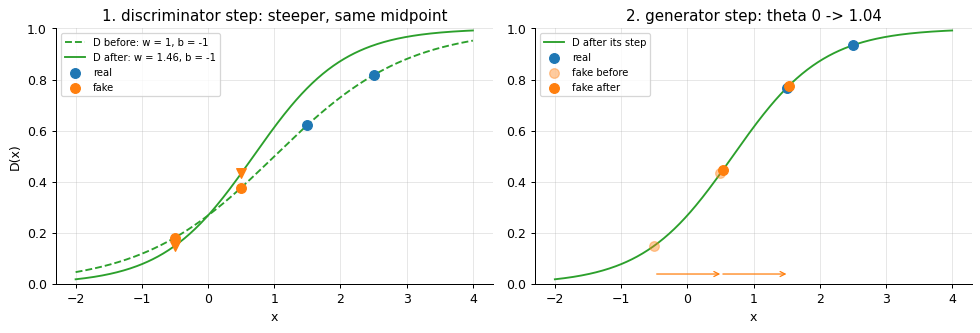

In [4]:
xx = np.linspace(-2, 4, 300)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(xx, sig(w0 * xx + b0), "tab:green", ls="--", label=f"D before: w = {w0:.0f}, b = {b0:.0f}")
ax[0].plot(xx, sig(w1 * xx + b1), "tab:green", label=f"D after: w = {w1:.2f}, b = {b1:.0f}")
ax[0].scatter(x_real, D_real, c="tab:blue", s=60, zorder=3, label="real")
ax[0].scatter(x_fake, D_fake, c="tab:orange", s=60, zorder=3, label="fake")
ax[0].scatter(x_fake, D_fake1, c="tab:orange", s=60, marker="v", zorder=3)
ax[0].set(title="1. discriminator step: steeper, same midpoint", xlabel="x", ylabel="D(x)", ylim=(0, 1)); ax[0].legend(fontsize=8)
ax[1].plot(xx, sig(w1 * xx + b1), "tab:green", label="D after its step")
ax[1].scatter(x_real, sig(w1 * x_real + b1), c="tab:blue", s=60, zorder=3, label="real")
ax[1].scatter(x_fake, D_fake1, c="tab:orange", s=60, zorder=3, alpha=0.4, label="fake before")
ax[1].scatter(theta1 + z_toy, D_fake2, c="tab:orange", s=60, zorder=3, label="fake after")
for a, c in zip(x_fake, theta1 + z_toy):
    ax[1].annotate("", xy=(c, 0.04), xytext=(a, 0.04), arrowprops=dict(arrowstyle="->", color="tab:orange"))
ax[1].set(title=f"2. generator step: theta 0 -> {theta1:.2f}", xlabel="x", ylim=(0, 1)); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What just happened?** One round of the game, with every number visible.

- **Discriminator step.** $D$ already separates the groups (0.622 and 0.818 on the real points, 0.182 and 0.378 on the fakes). Its boundary $wx + b = 0$ sits at $x = 1$, exactly midway between the two groups, so the pulls on $b$ from the real and fake points cancel ($\partial L_D/\partial b = 0$) and only the slope changes: $w = 1 \to 1.462$. $D$ becomes more confident: the fakes now get 0.150 and 0.433.
- **Generator step.** $\partial L_G / \partial\theta = -1.036$, so $\theta$ moves from 0 to 1.036 and both fakes move right, towards the data, where $D$ gives them 0.446 and 0.777. The generator never sees a real example: everything it knows about the data comes through the gradient of $D$.
- The minimax loss would have given $-0.427$, 2.4 times smaller, because $D$ rejects the fakes. Section 4 explains this gap in general.

## 3. A 1-D GAN from scratch

Same game, now with small MLPs and the mixture of section 1 as data.

- $G$: $\mathbf{z} \in \mathbb{R}^4 \to 64 \to 64 \to 1$, LeakyReLU. $D$: $1 \to 64 \to 64 \to 1$, LeakyReLU, with a **logit** output: the sigmoid lives inside `BCEWithLogitsLoss`, which is numerically safer than `log(sigmoid(.))`.
- Adam with $\eta = 5 \cdot 10^{-4}$ and $\beta_1 = 0.5$ (the usual GAN choice: less momentum, because the target keeps moving), $m = 256$, $k = 1$, 4000 iterations.
- Why $d_z = 4$ and not 1? With a 1-D $z$ the density of $G(z)$ is $p_z(z)/|G'(z)|$, which has sharp spikes wherever $G' = 0$. Extra noise dimensions smooth $p_g$ out.

At snapshots we store $p_g$ (a histogram of 50,000 samples on bins of width 0.1), $D(x)$ on a grid, a copy of $G$, and $\mathrm{JS}(p_{\text{data}} \,\|\, p_g)$ computed on the grid (section 4 shows why this divergence is the one the game minimises).

In [5]:
def mlp(d_in, d_out, h=64):
    return nn.Sequential(nn.Linear(d_in, h), nn.LeakyReLU(0.2), nn.Linear(h, h), nn.LeakyReLU(0.2), nn.Linear(h, d_out))

DZ1 = 4                                     # noise dimension of the 1-D generator
GRID = np.linspace(-5, 5, 101)              # where we evaluate densities and D(x)
EDGES = np.linspace(-5.05, 5.05, 102)       # histogram bins of width 0.1 centred on GRID
GRID_T = torch.tensor(GRID, dtype=torch.float32).unsqueeze(1)
PD_GRID = p_data(GRID)

def density_of_samples(s):
    h, _ = np.histogram(s, bins=EDGES)
    return h / (len(s) * 0.1)

def kl_grid(p, q, dx):
    # KL(p || q) for densities on a grid; terms with p = 0 count 0
    ok = p > 0
    return np.sum(p[ok] * np.log(p[ok] / q[ok])) * dx

def js_grid(p, q, dx):
    m = (p + q) / 2
    return 0.5 * kl_grid(p, m, dx) + 0.5 * kl_grid(q, m, dx)

SNAP_STEPS = sorted(set(range(0, 201, 10)) | set(range(250, 1001, 50)) | set(range(1200, 4001, 200)))

def train_gan_1d(steps=4000, m=256, lr=5e-4, seed=0):
    torch.manual_seed(seed)
    G, D = mlp(DZ1, 1), mlp(1, 1)
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    ones, zeros = torch.ones(m, 1), torch.zeros(m, 1)
    z_eval = torch.randn(50_000, DZ1)
    snaps, losses = {}, []
    for step in range(steps + 1):
        if step in SNAP_STEPS:
            with torch.no_grad():
                pg = density_of_samples(G(z_eval).squeeze(1).numpy())
                d = torch.sigmoid(D(GRID_T)).squeeze(1).numpy()
            snaps[step] = dict(pg=pg, D=d, G=copy.deepcopy(G.state_dict()), js=js_grid(PD_GRID, pg, 0.1))
        if step == steps:
            break
        # 1. discriminator step: real -> 1, fake -> 0 (fake detached: no gradient into G)
        x, fake = sample_data(m), G(torch.randn(m, DZ1)).detach()
        loss_D = bce(D(x), ones) + bce(D(fake), zeros)
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # 2. generator step, non-saturating loss: make D call the fakes real
        loss_G = bce(D(G(torch.randn(m, DZ1))), ones)
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
        losses.append((loss_D.item(), loss_G.item()))
    return G, D, snaps, np.array(losses)

t0 = time.time()
G1, D1, snaps1, losses1 = train_gan_1d()
print(f"trained in {time.time() - t0:.0f} s")
for s in [0, 50, 100, 200, 500, 1000, 2000, 4000]:
    print(f"step {s:4d}: JS(p_data || p_g) = {snaps1[s]['js']:.3f}")
with torch.no_grad():
    xs1 = G1(torch.randn(100_000, DZ1)).squeeze(1).numpy()
print(f"final samples: mean {xs1.mean():.3f} (data 0.400), std {xs1.std():.3f} (data 2.022), "
      f"fraction below 0 {np.mean(xs1 < 0):.3f} (data 0.400)")
lD, lG = losses1[-500:].mean(0)
print(f"mean losses over the last 500 steps: L_D = {lD:.3f} (equilibrium 2 log 2 = {2 * np.log(2):.3f}), "
      f"L_G = {lG:.3f} (equilibrium log 2 = {np.log(2):.3f})")
on_data = PD_GRID > 0.05
print(f"final D(x) where p_data > 0.05: mean {snaps1[4000]['D'][on_data].mean():.3f}, "
      f"range [{snaps1[4000]['D'][on_data].min():.3f}, {snaps1[4000]['D'][on_data].max():.3f}] (equilibrium 0.5)")

trained in 6 s
step    0: JS(p_data || p_g) = 0.692
step   50: JS(p_data || p_g) = 0.199
step  100: JS(p_data || p_g) = 0.192
step  200: JS(p_data || p_g) = 0.151
step  500: JS(p_data || p_g) = 0.114
step 1000: JS(p_data || p_g) = 0.098
step 2000: JS(p_data || p_g) = 0.104
step 4000: JS(p_data || p_g) = 0.027
final samples: mean 0.440 (data 0.400), std 1.953 (data 2.022), fraction below 0 0.397 (data 0.400)
mean losses over the last 500 steps: L_D = 1.384 (equilibrium 2 log 2 = 1.386), L_G = 0.700 (equilibrium log 2 = 0.693)
final D(x) where p_data > 0.05: mean 0.506, range [0.461, 0.560] (equilibrium 0.5)


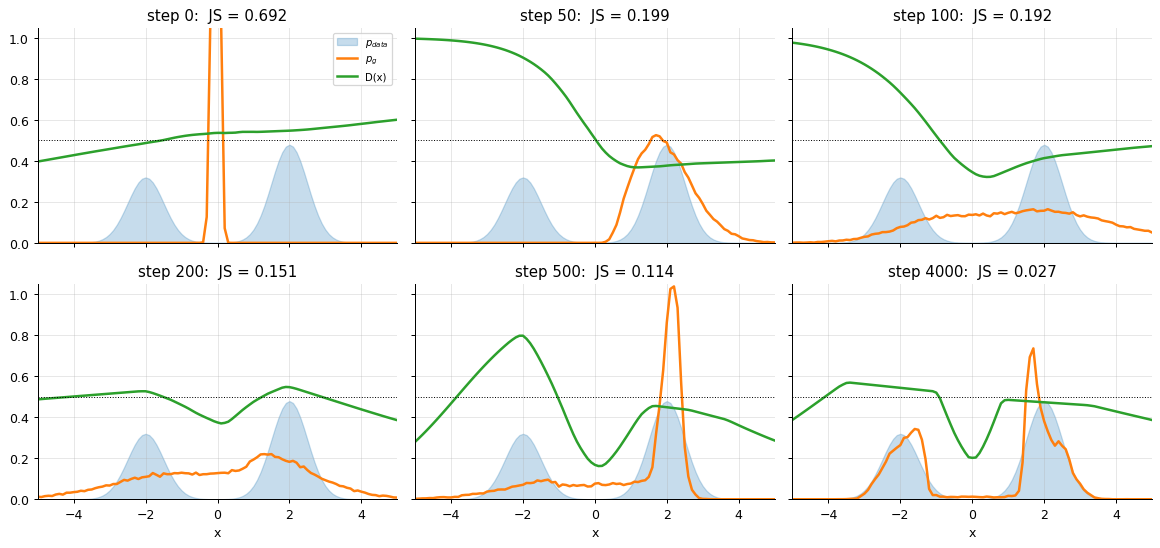

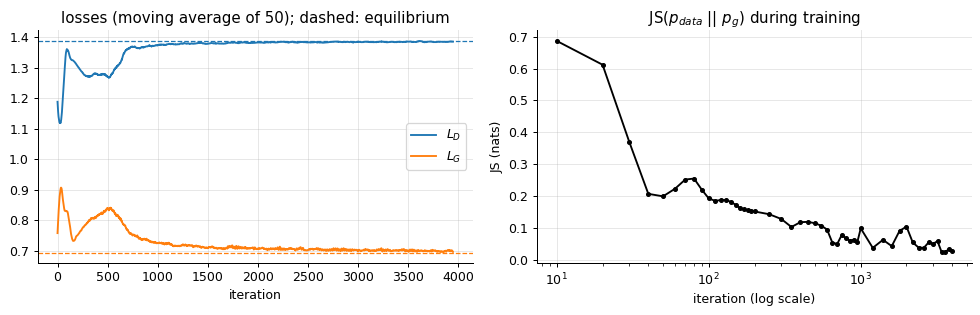

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(13, 6.2), sharex=True, sharey=True)
for ax, s in zip(axs.flat, [0, 50, 100, 200, 500, 4000]):
    ax.fill_between(GRID, PD_GRID, color="tab:blue", alpha=0.25, label="$p_{data}$")
    ax.plot(GRID, snaps1[s]["pg"], "tab:orange", lw=2, label="$p_g$")
    ax.plot(GRID, snaps1[s]["D"], "tab:green", lw=2, label="D(x)")
    ax.axhline(0.5, color="k", lw=0.8, ls=":")
    ax.set(title=f"step {s}:  JS = {snaps1[s]['js']:.3f}", ylim=(0, 1.05), xlim=(-5, 5))
axs[0, 0].legend(fontsize=8)
for ax in axs[1]: ax.set_xlabel("x")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
smooth = lambda v, k=50: np.convolve(v, np.ones(k) / k, mode="valid")
ax[0].plot(smooth(losses1[:, 0]), label="$L_D$"); ax[0].plot(smooth(losses1[:, 1]), label="$L_G$")
ax[0].axhline(2 * np.log(2), color="tab:blue", ls="--", lw=1); ax[0].axhline(np.log(2), color="tab:orange", ls="--", lw=1)
ax[0].set(title="losses (moving average of 50); dashed: equilibrium", xlabel="iteration"); ax[0].legend()
ks_ = [s for s in SNAP_STEPS if s > 0]
ax[1].plot(ks_, [snaps1[s]["js"] for s in ks_], "k.-"); ax[1].set_xscale("log")
ax[1].set(title="JS($p_{data}$ || $p_g$) during training", xlabel="iteration (log scale)", ylabel="JS (nats)")
plt.tight_layout(); plt.show()

**What just happened?** The generator started as a narrow spike at 0 (JS = 0.692, essentially the maximum $\log 2 = 0.693$: the two distributions barely overlap) and ended close to the data (JS = 0.027 at iteration 4000), with mean 0.440, standard deviation 1.953 and 39.7% of the samples below 0 (data: 0.400, 2.022 and 40%).

**Things to notice.**
- **Iterations 10–60: one mode.** $D$ first says "real is on the right" (the heavier mode), so $G$ moves all its mass to the right mode: an episode of **mode collapse**. Then $D$ penalises the right mode and $G$ spreads into a broad blanket over both modes and the gap (iterations 100–200). Around iteration 500 it collapses again into a sharp peak on the right mode, with only a thin tail on the left, before settling on two modes. This back-and-forth is the game's rotation (section 5) at work.
- $D$ is **high where $p_{\text{data}} \gt p_g$ and low where $p_g \gt p_{\text{data}}$**: it points $G$ to where mass is missing. At the end $D \approx 0.5$ on the data (between 0.46 and 0.56), with a dip in the gap: the thin bridge of fakes between the modes that a continuous $G$ cannot remove (section 1).
- The losses do **not** go to zero. They settle at $L_D = 1.384$ and $L_G = 0.700$, the equilibrium values $2\log 2 = 1.386$ and $\log 2 = 0.693$, where neither player can improve. JS keeps oscillating between about 0.03 and 0.10 after iteration 1000. A GAN loss curve says little about sample quality: we monitor samples and metrics instead (section 9).

## 4. The theory, checked: optimal discriminator, Jensen–Shannon, saturation

### 4a. The optimal discriminator

Write both expectations as integrals over $\mathbf{x}$. The second one is over $\mathbf{z}$, but the expectation of a function of $G(\mathbf{z})$ is the expectation over the distribution of $G(\mathbf{z})$, which is $p_g$:

$$
V(D, G) = \int \Big[p_{\text{data}}(\mathbf{x})\log D(\mathbf{x}) + p_g(\mathbf{x})\log\big(1 - D(\mathbf{x})\big)\Big]\,d\mathbf{x}.
$$

$D$ is free at every $\mathbf{x}$ separately, so we maximise the integrand pointwise. With $a = p_{\text{data}}(\mathbf{x})$, $b = p_g(\mathbf{x})$ and $y = D(\mathbf{x})$: $f(y) = a\log y + b\log(1 - y)$ has $f'(y) = a/y - b/(1 - y) = 0$ at $y = a/(a + b)$, and $f'' = -a/y^2 - b/(1-y)^2 \lt 0$, so it is the maximum:

$$
D^*(\mathbf{x}) = \frac{p_{\text{data}}(\mathbf{x})}{p_{\text{data}}(\mathbf{x}) + p_g(\mathbf{x})}.
$$

**Check.** Freeze the generator of step 200 (broad, far from the data), train a fresh discriminator against it until it stops improving, and compare with the formula. $p_{\text{data}}$ is known exactly; $p_g$ is a histogram of 2 million samples.

In [7]:
G200 = mlp(DZ1, 1); G200.load_state_dict(snaps1[200]["G"]); G200.requires_grad_(False)
with torch.no_grad():
    s200 = G200(torch.randn(2_000_000, DZ1)).squeeze(1).numpy()
pg200 = density_of_samples(s200)
D_star = PD_GRID / np.maximum(PD_GRID + pg200, 1e-12)

torch.manual_seed(1)
D_fix = mlp(1, 1)
opt = torch.optim.Adam(D_fix.parameters(), lr=1e-3)
bce = nn.BCEWithLogitsLoss()
t0 = time.time()
for step in range(3000):
    x = sample_data(1024)
    with torch.no_grad():
        fake = G200(torch.randn(1024, DZ1))
    loss = bce(D_fix(x), torch.ones(1024, 1)) + bce(D_fix(fake), torch.zeros(1024, 1))
    opt.zero_grad(); loss.backward(); opt.step()
with torch.no_grad():
    D_trained = torch.sigmoid(D_fix(GRID_T)).squeeze(1).numpy()
mask = (PD_GRID + pg200) > 0.02
err = np.abs(D_trained - D_star)[mask]
print(f"D trained for 3000 steps against the frozen G of step 200 ({time.time() - t0:.0f} s)")
print(f"where p_data + p_g > 0.02 ({mask.sum()} of {len(GRID)} grid points): "
      f"mean |D - D*| = {err.mean():.3f}, max |D - D*| = {err.max():.3f}")
for x0 in [-2.0, 0.0, 1.0, 2.0, 3.0]:
    i = np.argmin(np.abs(GRID - x0))
    print(f"  x = {x0:4.1f}: p_data = {PD_GRID[i]:.3f}, p_g = {pg200[i]:.3f} -> D* = {D_star[i]:.3f}, trained D = {D_trained[i]:.3f}")
assert err.mean() < 0.05

D trained for 3000 steps against the frozen G of step 200 (5 s)
where p_data + p_g > 0.02 (90 of 101 grid points): mean |D - D*| = 0.010, max |D - D*| = 0.039
  x = -2.0: p_data = 0.319, p_g = 0.111 -> D* = 0.742, trained D = 0.749
  x =  0.0: p_data = 0.000, p_g = 0.127 -> D* = 0.002, trained D = 0.008
  x =  1.0: p_data = 0.065, p_g = 0.192 -> D* = 0.252, trained D = 0.240
  x =  2.0: p_data = 0.479, p_g = 0.186 -> D* = 0.721, trained D = 0.698
  x =  3.0: p_data = 0.065, p_g = 0.097 -> D* = 0.400, trained D = 0.377


### 4b. Plugging $D^*$ in: the game minimises the Jensen–Shannon divergence

Write $M = \frac{1}{2}(p_{\text{data}} + p_g)$, so that $\frac{p_{\text{data}}}{p_{\text{data}} + p_g} = \frac{1}{2}\frac{p_{\text{data}}}{M}$. Then

$$
V(G, D^*) = \int p_{\text{data}}\log\frac{p_{\text{data}}}{2M} + \int p_g\log\frac{p_g}{2M}
= -\log 4 + \mathrm{KL}(p_{\text{data}} \,\|\, M) + \mathrm{KL}(p_g \,\|\, M)
= -\log 4 + 2\,\mathrm{JS}(p_{\text{data}} \,\|\, p_g),
$$

because each density integrates to 1, so each $\log\frac{1}{2}$ contributes $-\log 2$. Since $0 \le \mathrm{JS} \le \log 2$, the value lies in $[-\log 4, 0]$, and its minimum $-\log 4 = -1.386$ is reached **only** when $p_g = p_{\text{data}}$, where $D^* = \frac{1}{2}$ everywhere. With an optimal discriminator at every step, training $G$ minimises the Jensen–Shannon divergence.

**Check.** Estimate $V$ with the trained $D$ by Monte Carlo and compare with $-\log 4 + 2\,\mathrm{JS}$. For the JS we need $p_g$ including its tails, so we use bins of width 0.02 on $[-9, 9]$ (the plotting grid $[-5, 5]$ cuts off part of $p_g$), with the exact bin probabilities of $p_{\text{data}}$ from its CDF. A trained $D$ is never better than $D^*$, so its value can only be lower, up to sampling noise.

In [8]:
edges_f = np.arange(-9, 9.0001, 0.02)
pg_bins = np.histogram(s200, bins=edges_f)[0] / len(s200)          # probability of each bin
pd_bins = np.diff(cdf_data(edges_f))
m_bins = (pg_bins + pd_bins) / 2
kl_bins = lambda a: np.sum(a[a > 0] * np.log(a[a > 0] / m_bins[a > 0]))
js200 = 0.5 * kl_bins(pd_bins) + 0.5 * kl_bins(pg_bins)
print(f"mass of p_g outside the plotting grid [-5, 5]: {np.mean(np.abs(s200) > 5.05):.3f}; outside [-9, 9]: {np.mean(np.abs(s200) > 9):.6f}")
with torch.no_grad():
    xr = sample_data(200_000); xf = G200(torch.randn(200_000, DZ1))
    V_trained = (F.logsigmoid(D_fix(xr)).mean() + F.logsigmoid(-D_fix(xf)).mean()).item()   # log(1 - sigmoid(a)) = logsigmoid(-a)
print(f"JS(p_data || p_g) for the G of step 200: {js200:.4f} nats (max log 2 = {np.log(2):.4f})")
print(f"V(G, D*) = -log 4 + 2 JS = {-np.log(4) + 2 * js200:.4f}")
print(f"V(G, trained D), Monte Carlo with 200,000 samples = {V_trained:.4f}  (should be at most V(G, D*))")
assert V_trained < -np.log(4) + 2 * js200 + 0.005
print(f"at the optimum p_g = p_data: V = -log 4 = {-np.log(4):.4f}, D* = 0.5")

mass of p_g outside the plotting grid [-5, 5]: 0.014; outside [-9, 9]: 0.000010


JS(p_data || p_g) for the G of step 200: 0.1552 nats (max log 2 = 0.6931)
V(G, D*) = -log 4 + 2 JS = -1.0759
V(G, trained D), Monte Carlo with 200,000 samples = -1.0769  (should be at most V(G, D*))
at the optimum p_g = p_data: V = -log 4 = -1.3863, D* = 0.5


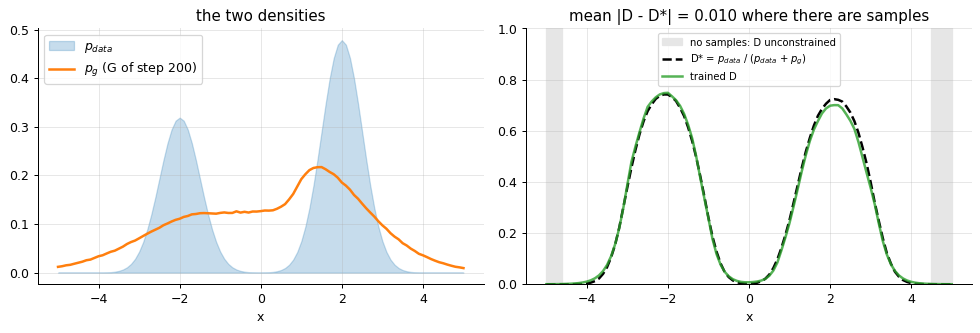

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].fill_between(GRID, PD_GRID, color="tab:blue", alpha=0.25, label="$p_{data}$")
ax[0].plot(GRID, pg200, "tab:orange", lw=2, label="$p_g$ (G of step 200)")
ax[0].set(title="the two densities", xlabel="x"); ax[0].legend()
ax[1].fill_between(GRID, 0, 1, where=~mask, color="0.9", label="no samples: D unconstrained")
ax[1].plot(GRID, D_star, "k--", lw=2, label="D* = $p_{data}$ / ($p_{data}$ + $p_g$)")
ax[1].plot(GRID, D_trained, "tab:green", lw=2, alpha=0.8, label="trained D")
ax[1].set(title=f"mean |D - D*| = {err.mean():.3f} where there are samples", xlabel="x", ylim=(0, 1)); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What just happened?** A discriminator trained by gradient descent landed on the formula: mean absolute error 0.010 (max 0.039) on the 90 grid points where there are samples. At $x = 0$ there is no data and plenty of fakes, so $D^* \approx 0$; at $x = -2$ there is about three times more data than fakes and $D^* = 0.742$ (trained: 0.749). The value of the game agrees too: $-\log 4 + 2\,\mathrm{JS} = -1.0759$ (JS = 0.1552) against $-1.0769$ by Monte Carlo with the trained $D$, just below the optimum as it must be.

**Things to notice.**
- Outside the samples (grey) the formula is $0/0$ and the trained $D$ is arbitrary. In high dimensions most of the space is like that: $D$ is only constrained near the data and the fakes.
- $D^*$ needs the **ratio** of the densities, never the densities themselves. This is the deep trick of GANs: a classifier estimates the density ratio, and the ratio is enough to train $G$.

### 4c. Why the minimax generator loss saturates

Write the discriminator's output on a fake as $D = \sigma(a)$, with $a$ the logit. The two generator losses, per sample, and their derivatives with respect to $a$:

| loss for $G$ | per sample | $\partial/\partial a$ | size when $D(G(\mathbf{z})) \to 0$ |
|---|---|---|---|
| minimax | $\log(1 - \sigma(a))$ | $-\sigma(a) = -D$ | $\to 0$: **saturates** |
| non-saturating | $-\log\sigma(a)$ | $-(1 - \sigma(a)) = -(1 - D)$ | $\to 1$ |

Early in training the fakes are bad and $D$ rejects them easily, so $D(G(\mathbf{z})) \approx 0$: the minimax loss sits on its flat part and the generator gets almost no gradient exactly when it needs it most. The non-saturating loss has the same fixed point ($D(G(\mathbf{z}))$ high) and a strong gradient when the fakes are bad. The price: it is no longer a zero-sum game. With $D = D^*$ it minimises $\mathrm{KL}(p_g \,\|\, p_{\text{data}}) - 2\,\mathrm{JS}$ (Arjovsky and Bottou, 2017), whose reverse KL punishes fakes where there is no data far more than missing data: it is **mode-seeking**, one root of mode collapse.

**Check.** Take the generator at initialisation, train $D$ against it for 300 steps, and measure the gradient of each generator loss.

mean D(G(z)) after training D against the initial G: 0.0072
gradient norm with respect to G's parameters: minimax 0.04269, non-saturating 4.2762 (100 times larger)
per-sample derivative with respect to the logit: minimax = -D, non-saturating = -(1 - D): checked


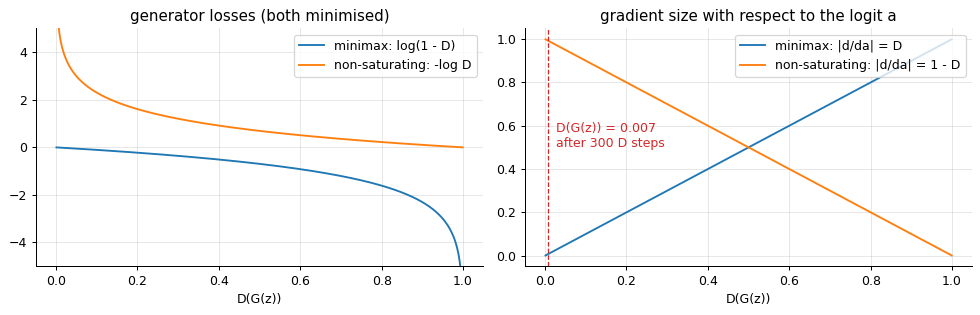

In [10]:
G0 = mlp(DZ1, 1); G0.load_state_dict(snaps1[0]["G"])
torch.manual_seed(2)
D0 = mlp(1, 1); opt = torch.optim.Adam(D0.parameters(), lr=1e-3)
for step in range(300):
    with torch.no_grad():
        fake = G0(torch.randn(256, DZ1))
    loss = bce(D0(sample_data(256)), torch.ones(256, 1)) + bce(D0(fake), torch.zeros(256, 1))
    opt.zero_grad(); loss.backward(); opt.step()

z = torch.randn(4096, DZ1)
logits = D0(G0(z))
loss_mm = -F.softplus(logits).mean()          # mean log(1 - sigmoid(a)), to be minimised by G
loss_ns = F.softplus(-logits).mean()          # mean -log sigmoid(a)
g_mm = torch.autograd.grad(loss_mm, list(G0.parameters()), retain_graph=True)
g_ns = torch.autograd.grad(loss_ns, list(G0.parameters()), retain_graph=True)
norm = lambda gs: torch.sqrt(sum((g ** 2).sum() for g in gs)).item()
# per-sample derivatives with respect to the logit: -D and -(1 - D)
da_mm = torch.autograd.grad(loss_mm * len(z), logits, retain_graph=True)[0]
da_ns = torch.autograd.grad(loss_ns * len(z), logits)[0]
Dz = torch.sigmoid(logits).detach()
assert torch.allclose(da_mm, -Dz, atol=1e-6) and torch.allclose(da_ns, -(1 - Dz), atol=1e-6)
print(f"mean D(G(z)) after training D against the initial G: {Dz.mean():.4f}")
print(f"gradient norm with respect to G's parameters: minimax {norm(g_mm):.5f}, non-saturating {norm(g_ns):.4f} "
      f"({norm(g_ns) / norm(g_mm):.0f} times larger)")
print("per-sample derivative with respect to the logit: minimax = -D, non-saturating = -(1 - D): checked")

d = np.linspace(0.001, 0.999, 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(d, np.log(1 - d), label="minimax: log(1 - D)"); ax[0].plot(d, -np.log(d), label="non-saturating: -log D")
ax[0].set(title="generator losses (both minimised)", xlabel="D(G(z))", ylim=(-5, 5)); ax[0].legend()
ax[1].plot(d, d, label="minimax: |d/da| = D"); ax[1].plot(d, 1 - d, label="non-saturating: |d/da| = 1 - D")
ax[1].axvline(Dz.mean().item(), color="tab:red", ls="--", lw=1)
ax[1].text(Dz.mean().item() + 0.02, 0.5, f"D(G(z)) = {Dz.mean():.3f}\nafter 300 D steps", color="tab:red")
ax[1].set(title="gradient size with respect to the logit a", xlabel="D(G(z))"); ax[1].legend(loc="upper right")
plt.tight_layout(); plt.show()

**What just happened?** After 300 steps the discriminator rejects the initial fakes with $D(G(\mathbf{z})) \approx 0.007$. The minimax loss then gives the generator a gradient 100 times smaller than the non-saturating loss (norms 0.043 and 4.28): in the minimax version, learning would barely start. This is why every practical GAN (and section 3) trains $G$ with $-\log D(G(\mathbf{z}))$, the same binary cross-entropy as $D$ but with the fake labels flipped to 1.

## 5. Two-player dynamics: the bilinear game

Gradient descent on one loss goes downhill. In a game each player goes downhill on its **own** loss, and the combined vector field can rotate. The smallest example is

$$
\min_x \max_y \; V(x, y) = xy .
$$

The only equilibrium is $(0, 0)$: there $V(0, y) = 0 = V(x, 0)$, so neither player can gain by moving alone.

**Simultaneous gradient steps** $x \leftarrow x - \eta y$, $y \leftarrow y + \eta x$ (both use the old values). Then

$$
(x - \eta y)^2 + (y + \eta x)^2 = (1 + \eta^2)(x^2 + y^2),
$$

because the cross terms $-2\eta xy$ and $+2\eta xy$ cancel. The distance to the equilibrium grows by $\sqrt{1 + \eta^2}$ at every step, **for every learning rate**: an outward spiral.

- **Alternating** steps ($y$ uses the new $x$, as in GAN training): the update matrix $\begin{pmatrix}1 & -\eta\\ \eta & 1 - \eta^2\end{pmatrix}$ has determinant 1, so the iterates stay on a closed orbit. Bounded, but they never converge.
- **Extragradient**: take a look-ahead step, then update with the gradient at the look-ahead point. The radius shrinks by $\sqrt{1 - \eta^2 + \eta^4} \lt 1$ per step.
- **Optimistic** gradient descent: $x_{t+1} = x_t - 2\eta y_t + \eta y_{t-1}$ (and the same for $y$), a cheap approximation of the look-ahead. It also converges.

simultaneous : distance to (0, 0) after 100 steps = 7.107   (max along the way 7.107)
alternating  : distance to (0, 0) after 100 steps = 1.043   (max along the way 1.054)
extragradient: distance to (0, 0) after 100 steps = 0.141   (max along the way 1.000)
optimistic   : distance to (0, 0) after 100 steps = 0.124   (max along the way 1.020)
predicted: simultaneous (1 + eta^2)^(T/2) = 7.107, extragradient (1 - eta^2 + eta^4)^(T/2) = 0.141


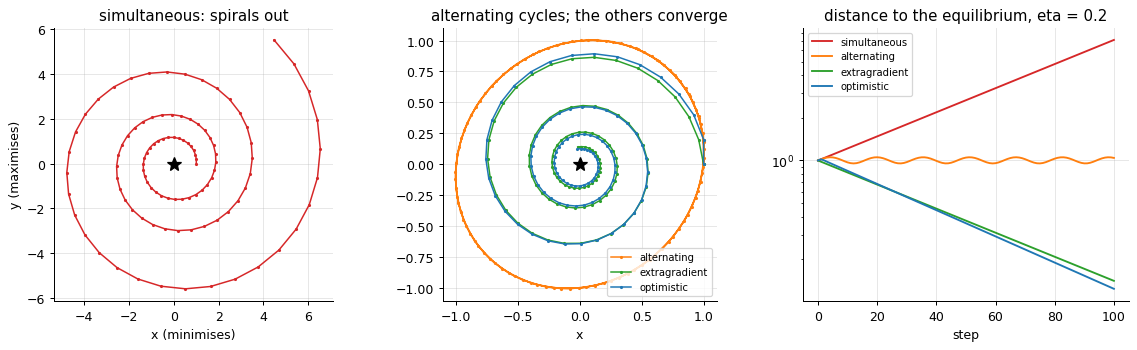

In [11]:
def bilinear(kind, eta=0.2, T=100, x=1.0, y=0.0):
    xp, yp = x, y
    out = [(x, y)]
    for t in range(T):
        if kind == "simultaneous":
            x, y = x - eta * y, y + eta * x
        elif kind == "alternating":
            x = x - eta * y
            y = y + eta * x
        elif kind == "extragradient":
            xh, yh = x - eta * y, y + eta * x          # look-ahead
            x, y = x - eta * yh, y + eta * xh
        elif kind == "optimistic":
            xn, yn = x - 2 * eta * y + eta * yp, y + 2 * eta * x - eta * xp
            xp, yp, x, y = x, y, xn, yn
        out.append((x, y))
    return np.array(out)

eta, T = 0.2, 100
traj = {k: bilinear(k, eta, T) for k in ["simultaneous", "alternating", "extragradient", "optimistic"]}
radius = {k: np.hypot(*v.T) for k, v in traj.items()}
for k, r in radius.items():
    print(f"{k:13s}: distance to (0, 0) after {T} steps = {r[-1]:.3f}   (max along the way {r.max():.3f})")
pred_sim, pred_eg = (1 + eta**2) ** (T / 2), (1 - eta**2 + eta**4) ** (T / 2)
print(f"predicted: simultaneous (1 + eta^2)^(T/2) = {pred_sim:.3f}, extragradient (1 - eta^2 + eta^4)^(T/2) = {pred_eg:.3f}")
assert np.isclose(radius["simultaneous"][-1], pred_sim) and np.isclose(radius["extragradient"][-1], pred_eg)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(*traj["simultaneous"].T, "tab:red", lw=1.2, marker=".", ms=3); ax[0].plot(0, 0, "k*", ms=12)
ax[0].set(title="simultaneous: spirals out", xlabel="x (minimises)", ylabel="y (maximises)", aspect="equal")
for k, c in [("alternating", "tab:orange"), ("extragradient", "tab:green"), ("optimistic", "tab:blue")]:
    ax[1].plot(*traj[k].T, c=c, lw=1.2, marker=".", ms=3, label=k)
ax[1].plot(0, 0, "k*", ms=12); ax[1].set(title="alternating cycles; the others converge", xlabel="x", aspect="equal"); ax[1].legend(fontsize=8)
for k, c in [("simultaneous", "tab:red"), ("alternating", "tab:orange"), ("extragradient", "tab:green"), ("optimistic", "tab:blue")]:
    ax[2].plot(radius[k], c=c, label=k)
ax[2].set_yscale("log"); ax[2].set(title=f"distance to the equilibrium, eta = {eta}", xlabel="step"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What just happened?** With $\eta = 0.2$ and 100 steps from $(1, 0)$: simultaneous steps end 7.107 away from the equilibrium, exactly $(1.04)^{50}$; alternating steps stay on an orbit of radius about 1; extragradient shrinks to 0.141, exactly $(0.9616)^{50}$; optimistic steps to 0.124.

**Why it matters for GANs.** Near an equilibrium a GAN behaves like a mixture of a potential (each player's own curvature) and a rotation like this one. The rotation makes the losses oscillate and the samples cycle (we saw $G$ chase the modes in section 3, and section 6 shows it on a ring). Remedies used in practice: small learning rates and $\beta_1 = 0.5$ in Adam; different learning rates for $D$ and $G$ (TTUR); extragradient or optimistic optimisers; regularising $D$ (gradient penalties, section 6); and evaluating an **exponential moving average** of the generator's weights, which averages the orbit out.

## 6. Mode collapse and the Wasserstein GAN

### 6a. When the supports do not overlap, JS gives no signal

Take $p = \mathcal{U}[0, 1]$ and a generator that can only shift: $q_\theta = \mathcal{U}[\theta, \theta + 1]$. If $|\theta| \ge 1$ the two supports are disjoint. Wherever $p \gt 0$ we have $q = 0$, so $M = p/2$ and $\mathrm{KL}(p \,\|\, M) = \int p \log 2 = \log 2$; the same holds for $q$. Hence

$$
\mathrm{JS}(p \,\|\, q_\theta) = \log 2 \quad \text{for every } |\theta| \ge 1, \qquad \frac{\partial\,\mathrm{JS}}{\partial\theta} = 0 .
$$

Nothing tells the generator which way to move. In high dimensions this is the normal situation, not a corner case: real images and early fakes live on thin, low-dimensional sets that almost never intersect, a perfect discriminator exists, and $D^*$ is 1 on the data and 0 on the fakes, with a flat (zero) gradient around both.

**The earth mover's distance.** Think of $p$ as a pile of earth and $q$ as a hole of the same volume. $W_1(p, q)$ is the minimal total work, mass times distance, needed to move the pile into the hole:

$$
W_1(p, q) = \inf_{\gamma \in \Pi(p, q)} \mathbb{E}_{(x, y) \sim \gamma}\,|x - y|, \qquad \text{in 1-D:} \quad W_1(p, q) = \int \big|F_p(t) - F_q(t)\big|\,dt,
$$

where $\Pi(p, q)$ is the set of joint distributions (transport plans) with marginals $p$ and $q$, and $F$ are the CDFs. For the two uniforms $W_1 = |\theta|$: it keeps growing with the distance and its gradient always points the right way. We check both claims, and a 5-bin example of the slides, from scratch and against SciPy.

CDF of p: [0.4 0.7 0.9 1.  1. ]   CDF of q: [0.  0.1 0.3 0.6 1. ]
W1 = sum |F_p - F_q| x bin width 1 = 2.00   scipy: 2.00
theta = 0.0:  JS = 0.0000  (log 2 = 0.6931)   W1 = 0.000
theta = 0.5:  JS = 0.3466  (log 2 = 0.6931)   W1 = 0.500
theta = 1.0:  JS = 0.6931  (log 2 = 0.6931)   W1 = 1.000
theta = 2.0:  JS = 0.6931  (log 2 = 0.6931)   W1 = 2.000


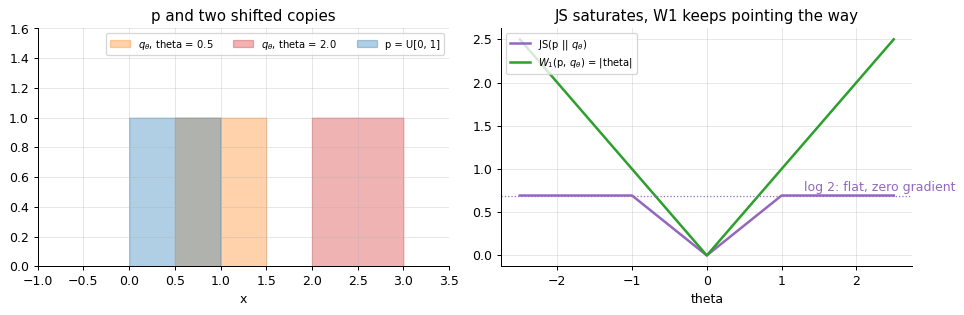

In [12]:
def w1_hist(p, q, dx):
    # earth mover's distance in 1-D between two histograms on the same bins: integral of |F_p - F_q|
    return np.sum(np.abs(np.cumsum(p) - np.cumsum(q))) * dx

def js_hist(p, q):
    # JS divergence (nats) between two probability vectors
    m = (p + q) / 2
    kl = lambda a: np.sum(a[a > 0] * np.log(a[a > 0] / m[a > 0]))
    return 0.5 * kl(p) + 0.5 * kl(q)

# the 5-bin example: move mass from the left bins to the right bins
p5, q5 = np.array([0.4, 0.3, 0.2, 0.1, 0.0]), np.array([0.0, 0.1, 0.2, 0.3, 0.4])
print("CDF of p:", np.cumsum(p5), "  CDF of q:", np.cumsum(q5))
print(f"W1 = sum |F_p - F_q| x bin width 1 = {w1_hist(p5, q5, 1.0):.2f}   scipy: "
      f"{stats.wasserstein_distance(np.arange(5), np.arange(5), p5, q5):.2f}")
assert np.isclose(w1_hist(p5, q5, 1.0), stats.wasserstein_distance(np.arange(5), np.arange(5), p5, q5))

# two uniforms of width 1, shifted by theta, on bins of width 0.01
dx = 0.01
centres = np.arange(-3, 4, dx) + dx / 2
unif = lambda a: ((centres > a) & (centres < a + 1)).astype(float) / np.sum((centres > a) & (centres < a + 1))
thetas = np.round(np.arange(-2.5, 2.51, 0.05), 2)
js_t = np.array([js_hist(unif(0), unif(t)) for t in thetas])
w_t = np.array([w1_hist(unif(0), unif(t), dx) for t in thetas])
for t in [0.0, 0.5, 1.0, 2.0]:
    i = np.argmin(np.abs(thetas - t))
    print(f"theta = {t:3.1f}:  JS = {js_t[i]:.4f}  (log 2 = {np.log(2):.4f})   W1 = {w_t[i]:.3f}")
i = np.argmin(np.abs(thetas - 0.5))
assert np.isclose(js_t[i], jensenshannon(unif(0), unif(0.5)) ** 2)            # scipy returns sqrt(JS)
assert np.isclose(w_t[i], stats.wasserstein_distance(centres, centres, unif(0), unif(0.5)))
assert np.allclose(js_t[np.abs(thetas) >= 1], np.log(2)) and np.allclose(w_t, np.abs(thetas), atol=0.01)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for t, c in [(0.5, "tab:orange"), (2.0, "tab:red")]:
    ax[0].fill_between(centres, unif(t) / dx, step="mid", alpha=0.35, color=c, label=f"$q_\\theta$, theta = {t}")
ax[0].fill_between(centres, unif(0) / dx, step="mid", alpha=0.35, color="tab:blue", label="p = U[0, 1]")
ax[0].set(title="p and two shifted copies", xlabel="x", xlim=(-1, 3.5), ylim=(0, 1.6)); ax[0].legend(fontsize=8, loc="upper right", ncol=3)
ax[1].plot(thetas, js_t, "tab:purple", lw=2, label="JS(p || $q_\\theta$)")
ax[1].plot(thetas, w_t, "tab:green", lw=2, label="$W_1$(p, $q_\\theta$) = |theta|")
ax[1].axhline(np.log(2), color="tab:purple", ls=":", lw=1); ax[1].text(1.3, 0.75, "log 2: flat, zero gradient", color="tab:purple")
ax[1].set(title="JS saturates, W1 keeps pointing the way", xlabel="theta"); ax[1].legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

**What just happened?** In the 5-bin example the CDFs differ by 0.4, 0.6, 0.6, 0.4 and 0 at the five bin edges, so $W_1 = 2.0$: on average every grain of mass travels two bins to the right. One optimal plan matches the mass in CDF order: 0.1 from bin 0 to bin 1, 0.2 from 0 to 2, 0.1 from 0 to 3, 0.2 from 1 to 3, 0.1 from 1 to 4, 0.2 from 2 to 4 and 0.1 from 3 to 4, a total cost of $0.1 + 0.4 + 0.3 + 0.4 + 0.3 + 0.4 + 0.1 = 2.0$. For the shifted uniforms JS is exactly $\log 2 = 0.6931$ as soon as $|\theta| \ge 1$, while $W_1 = |\theta|$ grows linearly. Our functions agree with `scipy.stats.wasserstein_distance` and `scipy.spatial.distance.jensenshannon`.

### 6b. The Wasserstein GAN

$W_1$ as written needs the best transport plan, which we cannot compute between image distributions. The **Kantorovich–Rubinstein duality** turns it into a maximisation over functions, which a network can do:

$$
W_1(p_{\text{data}}, p_g) = \sup_{\lVert f \rVert_L \le 1}\; \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}}\big[f(\mathbf{x})\big] - \mathbb{E}_{\mathbf{z} \sim p_z}\big[f(G(\mathbf{z}))\big],
$$

where the supremum runs over **1-Lipschitz** functions, $|f(\mathbf{x}) - f(\mathbf{y})| \le \lVert\mathbf{x} - \mathbf{y}\rVert$. The **WGAN** (Arjovsky et al., 2017) replaces the discriminator by a **critic** $f_w$: no sigmoid, a real-valued score, trained to maximise the difference of means; the generator minimises $-\mathbb{E}\,f_w(G(\mathbf{z}))$. The critic must stay 1-Lipschitz, otherwise it can blow the difference up to infinity:

- **Weight clipping** (the original WGAN): clip every weight to $[-c, c]$ after each step. Crude: it limits capacity and makes gradients explode or vanish depending on $c$.
- **Gradient penalty** (WGAN-GP, Gulrajani et al., 2017): add $\lambda\,\mathbb{E}_{\hat{\mathbf{x}}}\big[(\lVert\nabla_{\hat{\mathbf{x}}} f_w(\hat{\mathbf{x}})\rVert - 1)^2\big]$ on random points $\hat{\mathbf{x}} = \epsilon\mathbf{x} + (1 - \epsilon)G(\mathbf{z})$ between a real and a fake example. The optimal critic has gradient norm 1 along those lines, so the penalty pulls towards it. The critic is trained $k = 5$ times per generator step, because its estimate of $W_1$ must be good for the generator's gradient to be meaningful.
- **Spectral normalisation** (Miyato et al., 2018): divide each weight matrix by its largest singular value, so each layer is 1-Lipschitz; cheap, and also used with the standard GAN loss.

### 6c. Mode collapse on a ring of 8 Gaussians

The standard test: 8 Gaussians with standard deviation 0.05 on a circle of radius 2. Two numbers summarise a set of 1,000 samples:

- a sample is **high quality** if it lies within 3 standard deviations (0.15) of a mode centre;
- a mode is **covered** if at least 1% of the samples (10 of 1,000) are high-quality samples of that mode. A perfect generator puts 12.5% on each.

Both models use the **same networks** (as in Metz et al., 2017): $G$: $\mathbf{z} \in \mathbb{R}^{256} \to 128 \to 128 \to 2$ and $D$ or $f_w$: $2 \to 128 \to 128 \to 1$, ReLU; Adam with $\eta = 10^{-3}$, $m = 256$, and 2,000 generator steps each.

- **Vanilla GAN**: non-saturating loss, $k = 1$, $\beta = (0.5, 0.999)$.
- **WGAN-GP**: critic loss with $\lambda = 0.1$, $k = 5$, $\beta = (0.5, 0.9)$ as in the WGAN-GP paper.

We record the samples of a fixed set of 1,000 noise vectors every 100 generator steps.

In [13]:
RING = torch.tensor([[2 * np.cos(a), 2 * np.sin(a)] for a in np.arange(8) * 2 * np.pi / 8], dtype=torch.float32)
RING_SD = 0.05
def sample_ring(n):
    return RING[torch.randint(0, 8, (n,))] + RING_SD * torch.randn(n, 2)

def ring_metrics(s):
    # (number of covered modes, fraction of high-quality samples, samples per mode)
    d = torch.cdist(s, RING)
    dmin, idx = d.min(1)
    good = dmin < 3 * RING_SD
    counts = torch.bincount(idx[good], minlength=8)
    return int((counts >= 0.01 * len(s)).sum()), good.float().mean().item(), counts.tolist()

def mlp2(d_in, d_out, h=128):
    return nn.Sequential(nn.Linear(d_in, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(), nn.Linear(h, d_out))

DZ2 = 256
def train_ring(kind, g_steps=2000, m=256, lr=1e-3, lam=0.1, k=5, seed=0, every=100):
    torch.manual_seed(seed)
    G, D = mlp2(DZ2, 2), mlp2(2, 1)
    betas = (0.5, 0.999) if kind == "vanilla" else (0.5, 0.9)
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=betas)
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=betas)
    bce = nn.BCEWithLogitsLoss()
    z_fix = torch.randn(1000, DZ2)
    snaps = {}
    for step in range(g_steps + 1):
        if step % every == 0:
            with torch.no_grad():
                s = G(z_fix)
            snaps[step] = (s.numpy().copy(),) + ring_metrics(s)
        if step == g_steps:
            break
        for _ in range(1 if kind == "vanilla" else k):
            x, fake = sample_ring(m), G(torch.randn(m, DZ2)).detach()
            if kind == "vanilla":
                loss_D = bce(D(x), torch.ones(m, 1)) + bce(D(fake), torch.zeros(m, 1))
            else:
                eps = torch.rand(m, 1)
                x_hat = (eps * x + (1 - eps) * fake).requires_grad_(True)
                grad = torch.autograd.grad(D(x_hat).sum(), x_hat, create_graph=True)[0]
                loss_D = D(fake).mean() - D(x).mean() + lam * ((grad.norm(dim=1) - 1) ** 2).mean()
            opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        out = D(G(torch.randn(m, DZ2)))
        loss_G = bce(out, torch.ones(m, 1)) if kind == "vanilla" else -out.mean()
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    return G, D, snaps

ring_runs = {}
for kind in ["vanilla", "wgan-gp"]:
    t0 = time.time()
    ring_runs[kind] = train_ring(kind)
    print(f"{kind}: {time.time() - t0:.0f} s")
print("\nstep   vanilla: modes, quality    WGAN-GP: modes, quality")
for s in [0, 200, 400, 600, 800, 1000, 1500, 2000]:
    v, w = ring_runs["vanilla"][2][s], ring_runs["wgan-gp"][2][s]
    print(f"{s:4d}   {v[1]} / 8, {v[2]:.2f}               {w[1]} / 8, {w[2]:.2f}")

vanilla: 6 s


wgan-gp: 26 s

step   vanilla: modes, quality    WGAN-GP: modes, quality
   0   0 / 8, 0.00               0 / 8, 0.00
 200   0 / 8, 0.00               0 / 8, 0.01
 400   1 / 8, 0.05               2 / 8, 0.07
 600   1 / 8, 0.01               6 / 8, 0.11
 800   1 / 8, 0.07               7 / 8, 0.21
1000   0 / 8, 0.01               8 / 8, 0.34
1500   1 / 8, 0.04               8 / 8, 0.58
2000   0 / 8, 0.00               8 / 8, 0.58


vanilla, mode nearest to most samples, every 100 steps: [3, 6, 0, 1, 3, 4, 4, 5, 5, 7, 7, 7, 7, 6, 5, 5, 4, 4, 2, 0]
share of samples near that one mode: median 0.91; modes visited over time: 8 of 8; changes of the main mode: 12 in 19 intervals
WGAN-GP critic: gradient norm on interpolates, mean 1.45 (target 1), estimated W1 = E f(real) - E f(fake) = 0.153


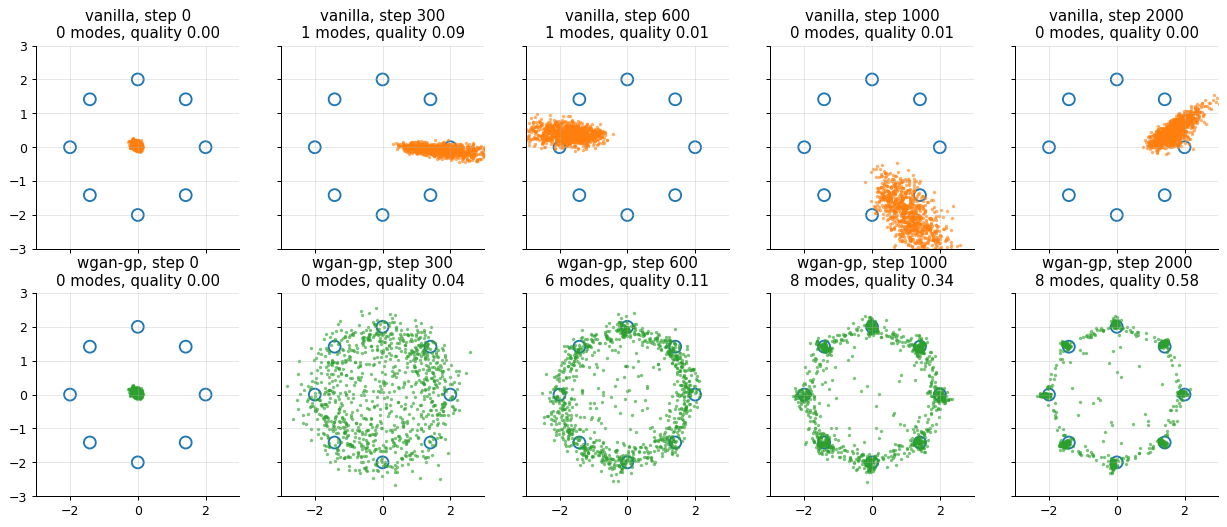

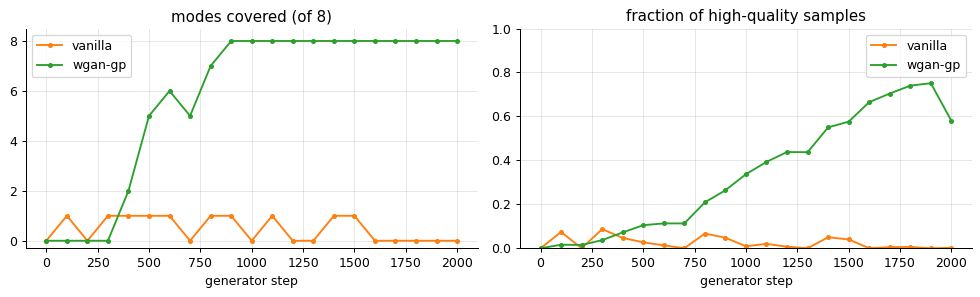

In [14]:
# mode hopping: which mode holds most of the vanilla samples at each snapshot?
snapv = ring_runs["vanilla"][2]
steps_v = sorted(snapv)
nearest = lambda s: torch.cdist(torch.tensor(s), RING).argmin(1).numpy()
main_mode = [int(np.bincount(nearest(snapv[s][0]), minlength=8).argmax()) for s in steps_v[1:]]
share = [np.bincount(nearest(snapv[s][0]), minlength=8).max() / 1000 for s in steps_v[1:]]
print("vanilla, mode nearest to most samples, every 100 steps:", main_mode)
print(f"share of samples near that one mode: median {np.median(share):.2f}; "
      f"modes visited over time: {len(set(main_mode))} of 8; changes of the main mode: "
      f"{int(np.sum(np.diff(main_mode) != 0))} in {len(main_mode) - 1} intervals")
Gw, Dw = ring_runs["wgan-gp"][0], ring_runs["wgan-gp"][1]
x, fake = sample_ring(2000), Gw(torch.randn(2000, DZ2)).detach()
eps = torch.rand(2000, 1); x_hat = (eps * x + (1 - eps) * fake).requires_grad_(True)
gn = torch.autograd.grad(Dw(x_hat).sum(), x_hat)[0].norm(dim=1)
print(f"WGAN-GP critic: gradient norm on interpolates, mean {gn.mean():.2f} (target 1), "
      f"estimated W1 = E f(real) - E f(fake) = {(Dw(x).mean() - Dw(fake).mean()).item():.3f}")

fig, axs = plt.subplots(2, 5, figsize=(14, 5.8), sharex=True, sharey=True)
for r, kind in enumerate(["vanilla", "wgan-gp"]):
    for c, s in enumerate([0, 300, 600, 1000, 2000]):
        smp, nm, hq, _ = ring_runs[kind][2][s]
        ax = axs[r, c]
        ax.scatter(*RING.T, s=90, facecolors="none", edgecolors="tab:blue", lw=1.5)
        ax.scatter(*smp.T, s=3, c="tab:orange" if kind == "vanilla" else "tab:green", alpha=0.5)
        ax.set(xlim=(-3, 3), ylim=(-3, 3), aspect="equal", title=f"{kind}, step {s}\n{nm} modes, quality {hq:.2f}")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for kind, c in [("vanilla", "tab:orange"), ("wgan-gp", "tab:green")]:
    st = sorted(ring_runs[kind][2])
    ax[0].plot(st, [ring_runs[kind][2][s][1] for s in st], c=c, marker=".", label=kind)
    ax[1].plot(st, [ring_runs[kind][2][s][2] for s in st], c=c, marker=".", label=kind)
ax[0].set(title="modes covered (of 8)", xlabel="generator step", ylim=(-0.3, 8.5)); ax[0].legend()
ax[1].set(title="fraction of high-quality samples", xlabel="generator step", ylim=(0, 1)); ax[1].legend()
plt.tight_layout(); plt.show()

**What just happened?** Same networks, same learning rate, same number of generator steps, two very different outcomes.

- **Vanilla GAN: mode hopping.** At every snapshot most samples (median 91%) sit near **one** mode, and that mode keeps changing: 12 changes in 19 intervals of 100 steps, visiting all 8 modes in turn, but never more than one at a time. The generator puts its mass where the current $D$ says "real", $D$ learns to reject that spot, the generator jumps elsewhere. This is the rotation of section 5 at work, and the mode-seeking pull of the non-saturating loss (section 4c). Coverage stays at 0 or 1 of 8 modes, with almost no high-quality samples: the blob is also too wide.
- **WGAN-GP: all 8 modes.** The critic's score keeps a useful slope everywhere, so the generator is pushed towards every mode at once: 6 modes at step 600, all 8 from step 1000, and 58% high-quality samples at step 2000. The gradient penalty keeps the critic's gradient norm on the interpolates of order 1 (mean 1.45; $\lambda = 0.1$ is a soft constraint).
- Mode collapse is partly a matter of luck and hyperparameters: with other seeds the vanilla GAN sometimes finds most modes (exercise 3). The point is that the standard loss gives no force against collapse, while the Wasserstein loss does.

## 7. DCGAN on MNIST

### 7a. Transposed convolutions

A generator must go from a small tensor to a full image: it **upsamples**. A **transposed convolution** does it with learned weights. Each input pixel multiplies the whole kernel and the scaled kernel is pasted into the output, `stride` pixels apart; where the copies overlap, they add up. Output size:

$$
H_{\text{out}} = (H_{\text{in}} - 1)\cdot s - 2p + k .
$$

DCGAN uses $k = 4$, $s = 2$, $p = 1$: $H_{\text{out}} = 2H_{\text{in}}$, so $7 \to 14 \to 28$. The name: it is the **transpose** (adjoint) of a strided convolution, $\langle \mathrm{conv}(\mathbf{y}), \mathbf{x}\rangle = \langle \mathbf{y}, \mathrm{convT}(\mathbf{x})\rangle$. It is exactly the operation backpropagation uses to send gradients through a convolution. We check both statements, and compute a $2 \times 2 \to 5 \times 5$ example by hand.

by hand:
 [[ 1  1  3  2  2]
 [ 1  1  3  2  2]
 [ 4  4 10  6  6]
 [ 3  3  7  4  4]
 [ 3  3  7  4  4]]
F.conv_transpose2d gives the same 5x5 output: True
output size (H - 1) s - 2p + k: 5 | DCGAN, k=4, s=2, p=1: 7 -> 14 ->  28
<conv(y), x> = 184.1518   <y, convT(x)> = 184.1518


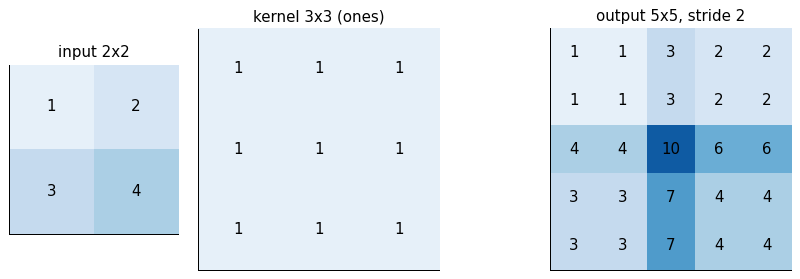

In [15]:
x_in = torch.tensor([[1., 2.], [3., 4.]])
K = torch.ones(3, 3)                                      # a 3x3 kernel of ones, stride 2, no padding
out = torch.zeros(5, 5)
for i in range(2):
    for j in range(2):
        out[2 * i:2 * i + 3, 2 * j:2 * j + 3] += x_in[i, j] * K    # paste a scaled copy of the kernel
ref = F.conv_transpose2d(x_in[None, None], K[None, None], stride=2)[0, 0]
print("by hand:\n", out.numpy().astype(int))
assert torch.equal(out, ref); print("F.conv_transpose2d gives the same 5x5 output: True")
print("output size (H - 1) s - 2p + k:", (2 - 1) * 2 - 0 + 3, "| DCGAN, k=4, s=2, p=1: 7 ->", (7 - 1) * 2 - 2 + 4,
      "-> ", (14 - 1) * 2 - 2 + 4)

# adjoint check on random tensors: <conv(y), x> = <y, convT(x)>
torch.manual_seed(0)
Wc = torch.randn(3, 5, 4, 4)                              # conv: 3 -> 5 channels, k=4, s=2, p=1 ; convT uses the same tensor
y_big, x_small = torch.randn(1, 3, 14, 14), torch.randn(1, 5, 7, 7)
lhs = (F.conv2d(y_big, Wc.transpose(0, 1), stride=2, padding=1) * x_small).sum()
rhs = (y_big * F.conv_transpose2d(x_small, Wc.transpose(0, 1), stride=2, padding=1)).sum()
print(f"<conv(y), x> = {lhs.item():.4f}   <y, convT(x)> = {rhs.item():.4f}")
assert torch.isclose(lhs, rhs, rtol=1e-4)

fig, ax = plt.subplots(1, 3, figsize=(10, 3.2), gridspec_kw=dict(width_ratios=[2, 3, 5]))
for a, M, t in [(ax[0], x_in, "input 2x2"), (ax[1], K, "kernel 3x3 (ones)"), (ax[2], out, "output 5x5, stride 2")]:
    a.imshow(M, cmap="Blues", vmin=0, vmax=12); a.set(title=t, xticks=[], yticks=[]); a.grid(False)
    for (i, j), v in np.ndenumerate(M.numpy()):
        a.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=12)
plt.tight_layout(); plt.show()

**What just happened?** Each input value painted a $3 \times 3$ square of itself; the squares overlap in the middle row and column, which add up (the centre gets $1 + 2 + 3 + 4 = 10$). That uneven overlap is the origin of the **checkerboard artefacts** of some generators: with $k$ not divisible by $s$, some output pixels receive more contributions than others. DCGAN's $k = 4$, $s = 2$ overlaps evenly. The adjoint check holds to rounding: a transposed convolution really is the transpose of a strided convolution.

### 7b. The DCGAN architecture

Radford et al. (2016) found a recipe that made convolutional GANs train reliably:

- no pooling: **strided convolutions** in $D$ to downsample, **transposed convolutions** in $G$ to upsample;
- **BatchNorm** in both networks, except the generator's output and the discriminator's input;
- **ReLU** in $G$ with **tanh** at the output (images scaled to $[-1, 1]$), **LeakyReLU** (slope 0.2) in $D$;
- no large fully connected hidden layers; Adam with $\eta = 2 \cdot 10^{-4}$, $\beta_1 = 0.5$; weights initialised from $\mathcal{N}(0, 0.02^2)$.

Our version is small enough for a CPU (two upsampling stages, 64 and 128 channels):

In [16]:
DZ = 64
class Generator(nn.Module):
    def __init__(self, dz=DZ, c=64, n_cls=0):
        super().__init__()
        self.n_cls = n_cls
        self.net = nn.Sequential(
            nn.Linear(dz + n_cls, 2 * c * 7 * 7), nn.Unflatten(1, (2 * c, 7, 7)),       # z -> 128 x 7 x 7
            nn.BatchNorm2d(2 * c), nn.ReLU(),
            nn.ConvTranspose2d(2 * c, c, 4, 2, 1), nn.BatchNorm2d(c), nn.ReLU(),       # -> 64 x 14 x 14
            nn.ConvTranspose2d(c, 1, 4, 2, 1), nn.Tanh())                               # -> 1 x 28 x 28, in [-1, 1]
    def forward(self, z, y=None):
        if self.n_cls:                                                                  # conditional GAN (section 8)
            z = torch.cat([z, F.one_hot(y, self.n_cls).float()], 1)
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, c=64, n_cls=0):
        super().__init__()
        self.n_cls = n_cls
        self.net = nn.Sequential(
            nn.Conv2d(1 + n_cls, c, 4, 2, 1), nn.LeakyReLU(0.2),                        # 1 x 28 x 28 -> 64 x 14 x 14
            nn.Conv2d(c, 2 * c, 4, 2, 1), nn.BatchNorm2d(2 * c), nn.LeakyReLU(0.2),    # -> 128 x 7 x 7
            nn.Flatten(), nn.Linear(2 * c * 7 * 7, 1))                                  # -> one logit
    def forward(self, x, y=None):
        if self.n_cls:                                                                  # label as constant extra channels
            x = torch.cat([x, F.one_hot(y, self.n_cls).float()[:, :, None, None].expand(-1, -1, 28, 28)], 1)
        return self.net(x)

def dcgan_init(mod):
    if isinstance(mod, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(mod.weight, 0, 0.02); nn.init.zeros_(mod.bias)
    elif isinstance(mod, nn.BatchNorm2d):
        nn.init.normal_(mod.weight, 1, 0.02); nn.init.zeros_(mod.bias)

def show_shapes(net, x):
    for layer in net.net:
        x = layer(x)
        if not isinstance(layer, (nn.BatchNorm2d, nn.ReLU, nn.LeakyReLU, nn.Tanh)):
            print(f"   {type(layer).__name__:16s} -> {tuple(x.shape[1:])}")

n_params = lambda net: sum(p.numel() for p in net.parameters())
print(f"Generator: {n_params(Generator()):,} parameters"); show_shapes(Generator(), torch.randn(2, DZ))
print(f"Discriminator: {n_params(Discriminator()):,} parameters"); show_shapes(Discriminator(), torch.randn(2, 1, 28, 28))

Generator: 540,225 parameters
   Linear           -> (6272,)
   Unflatten        -> (128, 7, 7)
   ConvTranspose2d  -> (64, 14, 14)
   ConvTranspose2d  -> (1, 28, 28)
Discriminator: 138,817 parameters
   Conv2d           -> (64, 14, 14)
   Conv2d           -> (128, 7, 7)
   Flatten          -> (6272,)
   Linear           -> (1,)


### 7c. Training

MNIST, 60,000 training images scaled to $[-1, 1]$; $m = 64$; 3 epochs (2,811 iterations); the same alternating loop as section 3, with the non-saturating loss. We save a copy of the generator after 50, 200 and 500 iterations and after every epoch, to watch the samples and, in section 9, the FID improve. Samples are drawn in `eval` mode (BatchNorm uses its running statistics).

In [17]:
mnist_train = torchvision.datasets.MNIST("data", train=True, download=True)
mnist_test = torchvision.datasets.MNIST("data", train=False, download=True)
X_train = (mnist_train.data.float() / 127.5 - 1).unsqueeze(1)          # 60000 x 1 x 28 x 28, in [-1, 1]
X_test = (mnist_test.data.float() / 127.5 - 1).unsqueeze(1)
Y_train, Y_test = mnist_train.targets, mnist_test.targets
print("train", tuple(X_train.shape), "test", tuple(X_test.shape), "range", X_train.min().item(), X_train.max().item())

def train_dcgan(epochs=3, m=64, n_cls=0, seed=0, save_at=(50, 200, 500)):
    torch.manual_seed(seed)
    G, D = Generator(n_cls=n_cls).to(device), Discriminator(n_cls=n_cls).to(device)
    G.apply(dcgan_init); D.apply(dcgan_init)
    opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    ones, zeros = torch.ones(m, 1, device=device), torch.zeros(m, 1, device=device)
    ckpt, log, it = {0: copy.deepcopy(G.state_dict())}, [], 0
    gen = torch.Generator().manual_seed(seed)
    for ep in range(epochs):
        t0, perm, stats_ep = time.time(), torch.randperm(len(X_train), generator=gen), []
        for i in range(0, len(X_train) - m + 1, m):
            idx = perm[i:i + m]
            x, y = X_train[idx].to(device), Y_train[idx].to(device)
            y_fake = torch.randint(0, 10, (m,), device=device) if n_cls else None
            fake = G(torch.randn(m, DZ, device=device), y_fake)
            d_real, d_fake = D(x, y if n_cls else None), D(fake.detach(), y_fake)
            loss_D = bce(d_real, ones) + bce(d_fake, zeros)
            opt_D.zero_grad(); loss_D.backward(); opt_D.step()
            loss_G = bce(D(fake, y_fake), ones)                      # non-saturating loss
            opt_G.zero_grad(); loss_G.backward(); opt_G.step()
            it += 1
            stats_ep.append((loss_D.item(), loss_G.item(), torch.sigmoid(d_real).mean().item(), torch.sigmoid(d_fake).mean().item()))
            if it in save_at:
                ckpt[it] = copy.deepcopy(G.state_dict())
        ckpt[it] = copy.deepcopy(G.state_dict())
        lD, lG, dr, df = np.mean(stats_ep, 0)
        log.append((ep + 1, it, lD, lG, dr, df))
        print(f"epoch {ep + 1} (iteration {it}): L_D {lD:.3f}  L_G {lG:.3f}  mean D(x) {dr:.3f}  mean D(G(z)) {df:.3f}  "
              f"[{time.time() - t0:.0f} s]")
    return G, D, ckpt, log

t0 = time.time()
G_dc, D_dc, ckpt_dc, log_dc = train_dcgan()
print(f"DCGAN trained in {time.time() - t0:.0f} s; checkpoints at iterations {sorted(ckpt_dc)}")

train (60000, 1, 28, 28) test (10000, 1, 28, 28) range -1.0 1.0


epoch 1 (iteration 937): L_D 0.537  L_G 2.077  mean D(x) 0.794  mean D(G(z)) 0.211  [35 s]


epoch 2 (iteration 1874): L_D 0.663  L_G 1.841  mean D(x) 0.760  mean D(G(z)) 0.241  [36 s]


epoch 3 (iteration 2811): L_D 0.779  L_G 1.644  mean D(x) 0.721  mean D(G(z)) 0.279  [36 s]
DCGAN trained in 107 s; checkpoints at iterations [0, 50, 200, 500, 937, 1874, 2811]


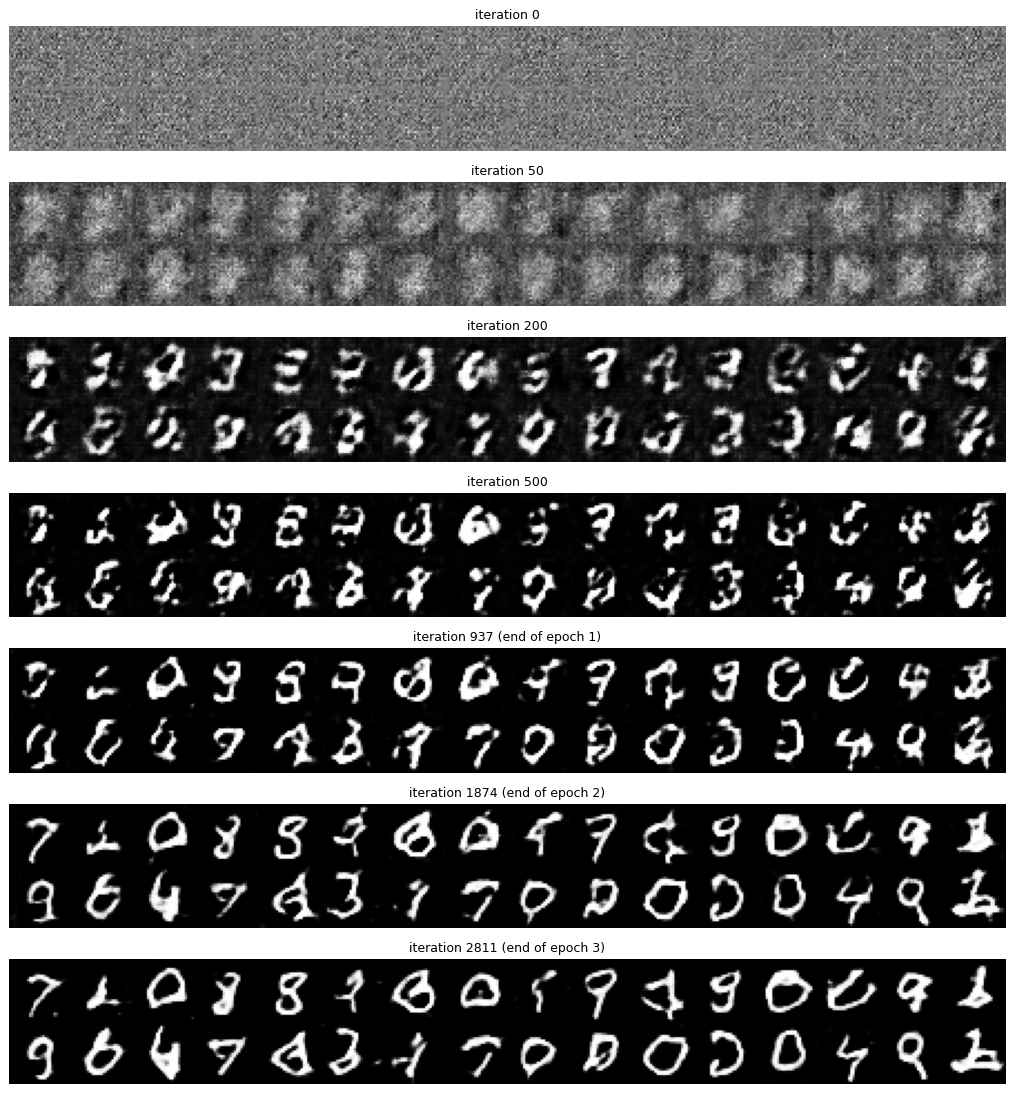

In [18]:
def load_G(state, n_cls=0):
    G = Generator(n_cls=n_cls).to(device); G.load_state_dict(state); G.eval()
    return G

def to_img(x):
    return ((x.detach().cpu().squeeze(1) + 1) / 2).clamp(0, 1).numpy()     # [-1, 1] -> [0, 1]

def tile(imgs, ncol):
    rows = [np.concatenate(list(imgs[r * ncol:(r + 1) * ncol]), 1) for r in range(len(imgs) // ncol)]
    return np.concatenate(rows, 0)

torch.manual_seed(123)
z_show = torch.randn(32, DZ, device=device)
show_its = sorted(ckpt_dc)
fig, axs = plt.subplots(len(show_its), 1, figsize=(12, 1.75 * len(show_its)))
for ax, it in zip(axs, show_its):
    with torch.no_grad():
        imgs = to_img(load_G(ckpt_dc[it])(z_show))
    ax.imshow(tile(imgs, 16), cmap="gray"); ax.set_axis_off()
    ax.set_title(f"iteration {it}" + (f" (end of epoch {it // 937})" if it % 937 == 0 and it else ""), fontsize=10)
plt.tight_layout(); plt.show()

**What just happened?** The same 32 noise vectors, decoded by the generator at each checkpoint. At iteration 0 the output is grey noise. After 50 iterations the generator has learned the global statistics (black background, a bright blob in the centre); after 200 there are stroke-like shapes; after 500 most samples are digit-like; after 1 to 3 epochs they are clearly digits, sharper than the samples of a VAE of similar size (Extra 3), though some are malformed. Each epoch takes about 45 s on 4 CPU threads. During the run $D(\mathbf{x})$ and $D(G(\mathbf{z}))$ stay far from 1 and 0 (0.72 and 0.28 in the last epoch): neither player wins, which is what a healthy GAN run looks like.

### 7d. Walking in the latent space

If the generator has learned a smooth map, a straight line between two noise vectors gives a smooth morph between two digits, not a cut-and-fade between images.

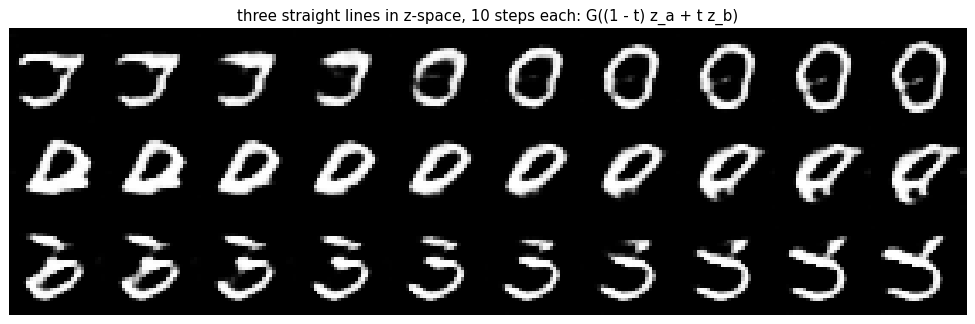

In [19]:
G_final = load_G(ckpt_dc[max(ckpt_dc)])
torch.manual_seed(7)
z_pairs = torch.randn(3, 2, DZ, device=device)
ts = torch.linspace(0, 1, 10, device=device)
rows = []
with torch.no_grad():
    for za, zb in z_pairs:
        rows.append(to_img(G_final((1 - ts)[:, None] * za + ts[:, None] * zb)))
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.imshow(tile(np.concatenate(rows), 10), cmap="gray"); ax.set_axis_off()
ax.set_title("three straight lines in z-space, 10 steps each: G((1 - t) z_a + t z_b)")
plt.tight_layout(); plt.show()

**Interpretation.** Each row moves smoothly: strokes thicken, bend and reconnect, and the intermediate images are mostly plausible digits. The generator has organised its latent space so that nearby $\mathbf{z}$ give similar images. This is what makes **GAN inversion** possible: find the $\mathbf{z}$ whose $G(\mathbf{z})$ matches a real image, then edit the image by moving $\mathbf{z}$.

### 7e. Is the generator just memorising?

A generator that copies training images would look perfect and be useless (and, for synthetic data, a privacy leak). Check: for each generated image, find its **nearest training image** (Euclidean distance in pixel space). Compare with the same distance for real **test** images, which are new digits by construction. Memorised samples would be much closer to the training set than test images are.

distance to the nearest training image (pixels in [0, 1], 784 dims): generated median 5.96, real test median 4.38
smallest distance among the 500 generated images: 2.33  (test images: 1.12)


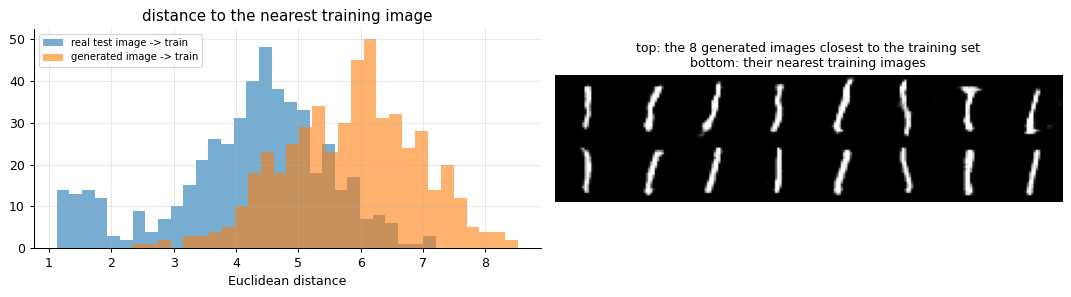

In [20]:
def nn_dist(a, b, chunk=500):
    # distance from each row of a to its nearest row of b, and the index
    a, b = a.reshape(len(a), -1), b.reshape(len(b), -1)
    d_all, i_all = [], []
    for i in range(0, len(a), chunk):
        d = torch.cdist(a[i:i + chunk], b)
        dm, im = d.min(1); d_all.append(dm); i_all.append(im)
    return torch.cat(d_all), torch.cat(i_all)

torch.manual_seed(11)
with torch.no_grad():
    gen = torch.tensor(to_img(G_final(torch.randn(500, DZ, device=device))))
train01 = (X_train + 1) / 2
d_gen, i_gen = nn_dist(gen, train01)
d_test, _ = nn_dist((X_test[:500] + 1) / 2, train01)
print(f"distance to the nearest training image (pixels in [0, 1], 784 dims): "
      f"generated median {d_gen.median():.2f}, real test median {d_test.median():.2f}")
print(f"smallest distance among the 500 generated images: {d_gen.min():.2f}  (test images: {d_test.min():.2f})")

fig = plt.figure(figsize=(12, 3.4))
ax = fig.add_subplot(1, 2, 1)
ax.hist(d_test.numpy(), bins=30, alpha=0.6, label="real test image -> train")
ax.hist(d_gen.numpy(), bins=30, alpha=0.6, label="generated image -> train")
ax.set(title="distance to the nearest training image", xlabel="Euclidean distance"); ax.legend(fontsize=8)
ax = fig.add_subplot(1, 2, 2)
order = torch.argsort(d_gen)[:8]                                      # the 8 most "suspicious" samples
pairs = np.concatenate([gen[order].numpy(), train01[i_gen[order]].squeeze(1).numpy()])
ax.imshow(tile(pairs, 8), cmap="gray"); ax.set_axis_off()
ax.set_title("top: the 8 generated images closest to the training set\nbottom: their nearest training images", fontsize=10)
plt.tight_layout(); plt.show()

**Interpretation.** The generated images are, if anything, *farther* from the training set than real test digits are (median distance 5.96 against 4.38; the closest generated image is at 2.33, while some test digits are near-duplicates of training digits, at 1.12). The 8 closest samples are all 1s, the simplest digit, and they are visibly different 1s from their nearest neighbours: no sign of copying. With 60,000 training images and a small generator, memorisation is unlikely. It becomes a real risk with small datasets, large generators and long training, which is exactly the setting of "synthetic data" for privacy. Nearest-neighbour checks are only a first test: they do not prove privacy, because a sample can leak information without being a pixel copy. Formal guarantees need differentially private training.

## 8. A conditional GAN: digits on demand

An unconditional GAN gives a random digit. A **conditional GAN** (Mirza and Osindero, 2014) gives the label $y$ to **both** networks: $G(\mathbf{z}, y)$ and $D(\mathbf{x}, y)$. The discriminator now asks "is this a real image **of class $y$**?", so the generator must produce the right class to fool it. The same classes as section 7 with `n_cls=10`: the generator concatenates a one-hot $y$ to $\mathbf{z}$, the discriminator receives $y$ as 10 constant extra channels. Fake labels are drawn uniformly. Two epochs.

epoch 1 (iteration 937): L_D 0.797  L_G 1.802  mean D(x) 0.715  mean D(G(z)) 0.284  [43 s]


epoch 2 (iteration 1874): L_D 0.957  L_G 1.379  mean D(x) 0.663  mean D(G(z)) 0.338  [42 s]
conditional DCGAN trained in 84 s


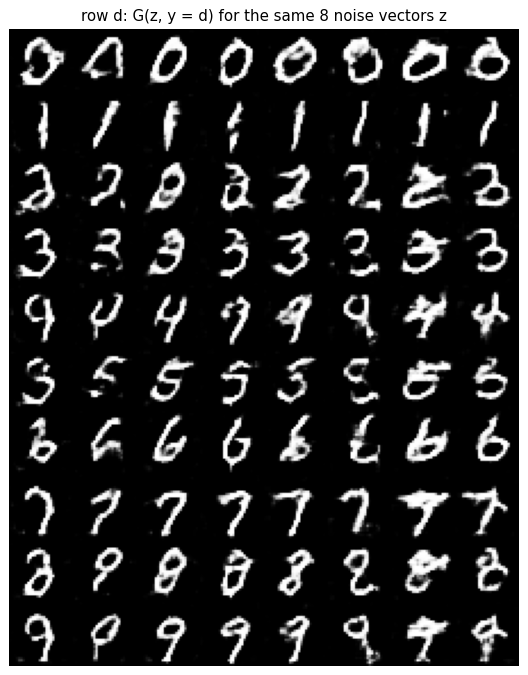

In [21]:
t0 = time.time()
G_cg, D_cg, ckpt_cg, log_cg = train_dcgan(epochs=2, n_cls=10, seed=1, save_at=())
print(f"conditional DCGAN trained in {time.time() - t0:.0f} s")
G_cond = load_G(ckpt_cg[max(ckpt_cg)], n_cls=10)
torch.manual_seed(5)
z8 = torch.randn(8, DZ, device=device)
with torch.no_grad():
    grid = [to_img(G_cond(z8, torch.full((8,), d, device=device))) for d in range(10)]
fig, ax = plt.subplots(figsize=(6.2, 7.6))
ax.imshow(tile(np.concatenate(grid), 8), cmap="gray"); ax.set_axis_off()
ax.set_title("row d: G(z, y = d) for the same 8 noise vectors z")
plt.tight_layout(); plt.show()

**Interpretation.** Each row is one requested digit, and the rows really are 0, 1, …, 9 (section 9 measures it with a classifier). Each **column** uses the same $\mathbf{z}$ for all ten digits, and the columns share a style: thickness, slant, width. The label controls the content and $\mathbf{z}$ the style. This split is the idea behind most controllable generators: pix2pix conditions on a whole image instead of a label, text-to-image models on a sentence.

## 9. Evaluation: FID from scratch

A GAN has no likelihood, so we cannot report a test log-likelihood as for a VAE. Looking at samples is necessary but subjective, and a model that memorises or drops half the classes can still produce beautiful samples. The standard metrics compare **features** of real and generated images, computed by a classifier trained on real data.

- **Inception Score** (IS): with a classifier $p(y \mid \mathbf{x})$, $\ \mathrm{IS} = \exp\big(\mathbb{E}_{\mathbf{x} \sim p_g}\,\mathrm{KL}\big(p(y \mid \mathbf{x}) \,\|\, p(y)\big)\big)$. High when each sample is classified confidently (quality) and the classes are balanced (diversity); between 1 and the number of classes. It never looks at real images.
- **Fréchet Inception Distance** (FID, Heusel et al., 2017): embed real and generated images (Inception-v3 pool features, 2048-d, in the standard version), fit a Gaussian to each set, and compute the Fréchet distance between the two Gaussians:

$$
\mathrm{FID} = \lVert \boldsymbol{\mu}_r - \boldsymbol{\mu}_g \rVert^2 + \operatorname{tr}\Big(\boldsymbol{\Sigma}_r + \boldsymbol{\Sigma}_g - 2\big(\boldsymbol{\Sigma}_r\boldsymbol{\Sigma}_g\big)^{1/2}\Big).
$$

Lower is better; 0 means the same mean and covariance. In 1-D it reduces to $(\mu_r - \mu_g)^2 + \sigma_r^2 + \sigma_g^2 - 2\sigma_r\sigma_g = (\mu_r - \mu_g)^2 + (\sigma_r - \sigma_g)^2$: a mean term and a spread term, so FID punishes both wrong content and missing diversity.

**By hand in 2-D.** $\boldsymbol{\mu}_r = (0, 0)$, $\boldsymbol{\Sigma}_r = \mathbf{I}$; $\boldsymbol{\mu}_g = (1, 0)$, $\boldsymbol{\Sigma}_g = \operatorname{diag}(4, 1)$. Then $\lVert\Delta\boldsymbol{\mu}\rVert^2 = 1$, $(\boldsymbol{\Sigma}_r\boldsymbol{\Sigma}_g)^{1/2} = \operatorname{diag}(2, 1)$, and the trace term is $(1 + 1) + (4 + 1) - 2(2 + 1) = 1$. So $\mathrm{FID} = 2$.

**Computing the matrix square root.** $\boldsymbol{\Sigma}_r\boldsymbol{\Sigma}_g$ is not symmetric, but it is similar to the symmetric matrix $\boldsymbol{\Sigma}_r^{1/2}\boldsymbol{\Sigma}_g\boldsymbol{\Sigma}_r^{1/2}$ (multiply by $\boldsymbol{\Sigma}_r^{1/2}$ on one side and its inverse on the other), which is positive semi-definite. So $\operatorname{tr}(\boldsymbol{\Sigma}_r\boldsymbol{\Sigma}_g)^{1/2} = \sum_i\sqrt{\lambda_i}$, with $\lambda_i$ the eigenvalues of $\boldsymbol{\Sigma}_r^{1/2}\boldsymbol{\Sigma}_g\boldsymbol{\Sigma}_r^{1/2}$: two symmetric eigendecompositions, stable even when a covariance is singular (dead ReLU features). We check it against `scipy.linalg.sqrtm`.

Inception-v3 is trained on ImageNet photos and is a poor judge of MNIST digits, so we train our own small MNIST classifier and use its 64-d penultimate layer as the feature space. The numbers are therefore an "FID-like" score: comparable within this notebook, not with published FIDs.

In [22]:
def frechet_distance(mu1, S1, mu2, S2):
    # ||mu1 - mu2||^2 + tr(S1 + S2 - 2 (S1 S2)^(1/2)), with tr (S1 S2)^(1/2) = sum sqrt(eig(S1^(1/2) S2 S1^(1/2)))
    w, V = np.linalg.eigh(S1)
    S1h = (V * np.sqrt(np.clip(w, 0, None))) @ V.T
    lam = np.linalg.eigvalsh(S1h @ S2 @ S1h)
    return float(np.sum((mu1 - mu2) ** 2) + np.trace(S1) + np.trace(S2) - 2 * np.sum(np.sqrt(np.clip(lam, 0, None))))

def frechet_scipy(mu1, S1, mu2, S2):
    return float(np.sum((mu1 - mu2) ** 2) + np.trace(S1 + S2 - 2 * linalg.sqrtm(S1 @ S2).real))

fd_2d = frechet_distance(np.zeros(2), np.eye(2), np.array([1.0, 0.0]), np.diag([4.0, 1.0]))
print(f"2-D example: FID = {fd_2d:.4f} (by hand: 1 + 1 = 2)")
assert np.isclose(fd_2d, 2.0)
for (m1, s1, m2, s2) in [(0, 1, 1, 2), (0, 1, 0, 3), (2, 1, 0, 1)]:
    fd = frechet_distance(np.array([float(m1)]), np.array([[s1 ** 2.0]]), np.array([float(m2)]), np.array([[s2 ** 2.0]]))
    print(f"1-D: N({m1}, {s1}^2) vs N({m2}, {s2}^2): FID = {fd:.4f}   (mu1 - mu2)^2 + (s1 - s2)^2 = {(m1 - m2) ** 2 + (s1 - s2) ** 2}")
    assert np.isclose(fd, (m1 - m2) ** 2 + (s1 - s2) ** 2)
# from samples: fit the Gaussians on 20,000 draws of the 2-D example
rng = np.random.default_rng(0)
a = rng.multivariate_normal([0, 0], np.eye(2), 20_000); b = rng.multivariate_normal([1, 0], np.diag([4, 1]), 20_000)
print(f"same example estimated from 20,000 samples each: {frechet_distance(a.mean(0), np.cov(a.T), b.mean(0), np.cov(b.T)):.3f}")
A, B = rng.normal(size=(30, 10)), rng.normal(size=(30, 10))
S1, S2 = A.T @ A / 30, B.T @ B / 30 + 0.5 * np.eye(10)
print(f"random 10-d covariances: eigenvalue version {frechet_distance(np.zeros(10), S1, np.ones(10), S2):.6f}, "
      f"scipy sqrtm {frechet_scipy(np.zeros(10), S1, np.ones(10), S2):.6f}")
assert np.isclose(frechet_distance(np.zeros(10), S1, np.ones(10), S2), frechet_scipy(np.zeros(10), S1, np.ones(10), S2))

2-D example: FID = 2.0000 (by hand: 1 + 1 = 2)
1-D: N(0, 1^2) vs N(1, 2^2): FID = 2.0000   (mu1 - mu2)^2 + (s1 - s2)^2 = 2
1-D: N(0, 1^2) vs N(0, 3^2): FID = 4.0000   (mu1 - mu2)^2 + (s1 - s2)^2 = 4
1-D: N(2, 1^2) vs N(0, 1^2): FID = 4.0000   (mu1 - mu2)^2 + (s1 - s2)^2 = 4
same example estimated from 20,000 samples each: 1.991
random 10-d covariances: eigenvalue version 11.969313, scipy sqrtm 11.969313


In [23]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                  nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                  nn.Flatten(), nn.Linear(32 * 7 * 7, 64), nn.ReLU())
        self.head = nn.Linear(64, 10)
    def forward(self, x):
        return self.head(self.body(x))

torch.manual_seed(0)
clf = Classifier().to(device)
opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
t0 = time.time()
perm = torch.randperm(len(X_train))
for i in range(0, len(X_train), 128):                      # one epoch
    idx = perm[i:i + 128]
    loss = F.cross_entropy(clf(X_train[idx].to(device)), Y_train[idx].to(device))
    opt.zero_grad(); loss.backward(); opt.step()
clf.eval().requires_grad_(False)

@torch.no_grad()
def feats_and_probs(x, bs=1000):
    f, p = [], []
    for i in range(0, len(x), bs):
        h = clf.body(x[i:i + bs].to(device)); f.append(h.cpu()); p.append(F.softmax(clf.head(h), 1).cpu())
    return torch.cat(f).numpy().astype(np.float64), torch.cat(p).numpy()

f_test, p_test = feats_and_probs(X_test)
acc = (p_test.argmax(1) == Y_test.numpy()).mean()
print(f"classifier trained in {time.time() - t0:.0f} s, test accuracy {acc:.4f}; feature dimension {f_test.shape[1]}")

classifier trained in 5 s, test accuracy 0.9725; feature dimension 64


Now the scores. The reference set is a random half of the test set, 5,000 images (a random half: MNIST's test set is sorted by writer group, and its two halves differ). We compare it with the other 5,000 test images (**real vs real**: the floor, set by sampling noise), with 5,000 samples from each saved DCGAN checkpoint, and with the conditional GAN. Besides FID and the classifier score (our IS), we compute **precision and recall** for generative models (Kynkäänniemi et al., 2019): put a ball around each real feature vector reaching its 3rd nearest real neighbour; **precision** is the fraction of generated samples inside the real balls (quality: do the fakes look real?), **recall** the fraction of real samples inside the balls of the generated set (coverage: is every kind of real digit produced?). They split what FID mixes into one number.

In [24]:
def gauss_stats(f):
    return f.mean(0), np.cov(f, rowvar=False)

def classifier_score(p):
    # exp( E_x KL(p(y|x) || p(y)) ), our MNIST version of the Inception Score
    py = p.mean(0, keepdims=True)
    return float(np.exp(np.mean(np.sum(p * (np.log(p + 1e-12) - np.log(py + 1e-12)), 1))))

def precision_recall(fr, fg, k=3, n=2000):
    fr, fg = torch.tensor(fr[:n]), torch.tensor(fg[:n])
    rr = torch.cdist(fr, fr).kthvalue(k + 1, dim=1).values        # k-th neighbour, excluding the point itself
    rg = torch.cdist(fg, fg).kthvalue(k + 1, dim=1).values
    d = torch.cdist(fg, fr)                                       # generated x real
    precision = (d <= rr[None, :]).any(1).float().mean().item()
    recall = (d.T <= rg[None, :]).any(1).float().mean().item()
    return precision, recall

half = torch.randperm(10_000, generator=torch.Generator().manual_seed(0)).numpy()
f_ref, f_other, p_other = f_test[half[:5000]], f_test[half[5000:]], p_test[half[5000:]]
mu_ref, S_ref = gauss_stats(f_ref)
@torch.no_grad()
def sample_G(G, n=5000, n_cls=0, seed=0):
    g = torch.Generator(device=device).manual_seed(seed)
    z = torch.randn(n, DZ, device=device, generator=g)
    y = torch.arange(n, device=device) % 10 if n_cls else None
    return torch.cat([G(z[i:i + 1000], None if y is None else y[i:i + 1000]) for i in range(0, n, 1000)]).cpu()

rows = {"real vs real": (f_other, p_other)}
for it in sorted(ckpt_dc):
    rows[f"DCGAN, iteration {it}"] = feats_and_probs(sample_G(load_G(ckpt_dc[it])))
rows["conditional GAN, 2 epochs"] = feats_and_probs(sample_G(G_cond, n_cls=10))
scores = {}
print(f"{'':28s} {'FID':>8s} {'IS':>6s} {'precision':>10s} {'recall':>7s}")
for name, (f, p) in rows.items():
    fid = frechet_distance(mu_ref, S_ref, *gauss_stats(f))
    pr, rc = precision_recall(f_ref, f)
    scores[name] = (fid, classifier_score(p), pr, rc)
    print(f"{name:28s} {fid:8.2f} {scores[name][1]:6.2f} {pr:10.3f} {rc:7.3f}")
print(f"(real test images: IS = {classifier_score(p_test):.2f}; the maximum is 10)")

                                  FID     IS  precision  recall
real vs real                     0.61   9.04      0.906   0.893
DCGAN, iteration 0            1798.65   1.00      0.000   0.000
DCGAN, iteration 50           1484.70   1.06      0.000   0.000


DCGAN, iteration 200           167.70   3.74      0.749   0.156
DCGAN, iteration 500            87.64   4.33      0.663   0.419
DCGAN, iteration 937            85.05   4.61      0.672   0.600


DCGAN, iteration 1874           45.87   5.56      0.651   0.809
DCGAN, iteration 2811           35.43   5.87      0.627   0.859
conditional GAN, 2 epochs        7.90   8.11      0.717   0.806
(real test images: IS = 9.04; the maximum is 10)


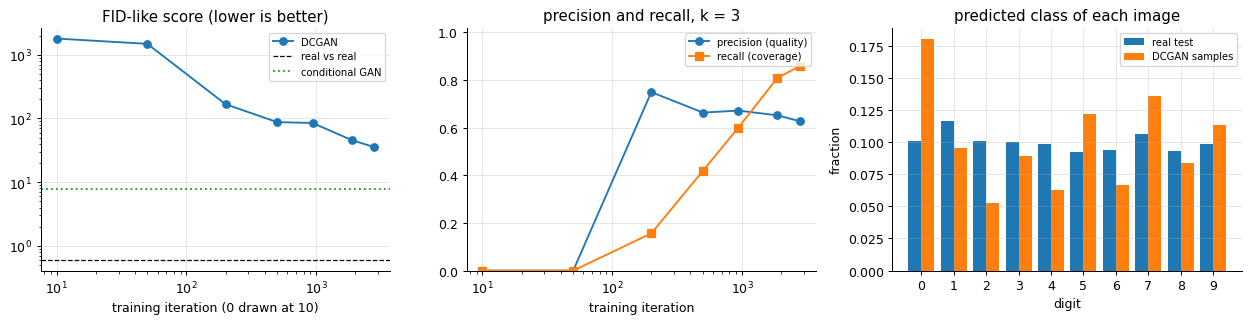

class fractions of the final DCGAN samples: [0.18  0.095 0.052 0.089 0.062 0.122 0.067 0.135 0.084 0.113]


In [25]:
its = sorted(ckpt_dc)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.7))
ax[0].plot([max(i, 10) for i in its], [scores[f"DCGAN, iteration {i}"][0] for i in its], "o-", label="DCGAN")
ax[0].axhline(scores["real vs real"][0], color="k", ls="--", lw=1, label="real vs real")
ax[0].axhline(scores["conditional GAN, 2 epochs"][0], color="tab:green", ls=":", lw=1.5, label="conditional GAN")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set(title="FID-like score (lower is better)", xlabel="training iteration (0 drawn at 10)"); ax[0].legend(fontsize=8)
ax[1].plot([max(i, 10) for i in its], [scores[f"DCGAN, iteration {i}"][2] for i in its], "o-", label="precision (quality)")
ax[1].plot([max(i, 10) for i in its], [scores[f"DCGAN, iteration {i}"][3] for i in its], "s-", label="recall (coverage)")
ax[1].set_xscale("log"); ax[1].set(title="precision and recall, k = 3", xlabel="training iteration", ylim=(0, 1.02)); ax[1].legend(fontsize=8)
p_final = rows[f"DCGAN, iteration {its[-1]}"][1]
ax[2].bar(np.arange(10) - 0.2, np.bincount(p_test.argmax(1), minlength=10) / len(p_test), 0.4, label="real test")
ax[2].bar(np.arange(10) + 0.2, np.bincount(p_final.argmax(1), minlength=10) / len(p_final), 0.4, label="DCGAN samples")
ax[2].set(title="predicted class of each image", xlabel="digit", xticks=range(10), ylabel="fraction"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
cls_frac = np.bincount(p_final.argmax(1), minlength=10) / len(p_final)
print("class fractions of the final DCGAN samples:", cls_frac.round(3))

**What just happened?** The metric moves with training, as it should. Real vs real gives the floor, 0.61 (two finite samples of the same distribution never match exactly). The untrained generator scores 1,799 in the units of this feature space; after 200 iterations it is down to 168, after 500 to 88, and after 3 epochs to 35.4. Progress is not monotone: the end of epoch 1 (85.1) is hardly better than iteration 500, the oscillation of section 5 again. **Precision** rises first (0.75 at iteration 200: the samples start to look like digits) while **recall** is still 0.16; recall then climbs to 0.86 (the variety of real digits gets covered) while precision settles around 0.63. The conditional GAN, after only 2 epochs, reaches 7.9: the label tells it how many of each digit to draw, which an unconditional GAN must discover by itself. Its classifier score is 8.11, against 5.87 for the DCGAN and 9.04 for real test images.

**Things to notice.**
- **FID needs many samples.** Its covariance term is estimated from the samples, so FID is biased upwards for small sets: always compare models with the same number of samples (50,000 is the convention for published numbers) and the same feature network.
- **The class histogram** is a cheap mode-dropping check that FID hides inside one number. Our DCGAN draws too many 0s (18% instead of 10%) and too few 2s (5.2%): a mild imbalance between modes, invisible in the sample grid.
- **IS** saturates quickly and never compares with real data: a generator that outputs one perfect image per class would get IS = 10. FID and precision/recall do not have that blind spot.

conditional GAN: the classifier agrees with the requested label for 90.1% of 10,000 samples
per requested digit: [0.986 0.998 0.907 0.884 0.911 0.887 0.951 0.983 0.749 0.754]


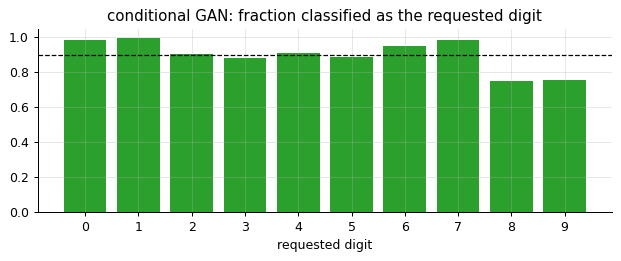

In [26]:
# does the label control the class? classify 1,000 samples of each requested digit
with torch.no_grad():
    yreq = torch.arange(10_000) % 10
    x_c = sample_G(G_cond, n=10_000, n_cls=10, seed=1)
_, p_c = feats_and_probs(x_c)
pred = p_c.argmax(1)
acc_c = (pred == yreq.numpy()).mean()
per_class = [(pred[yreq.numpy() == d] == d).mean() for d in range(10)]
print(f"conditional GAN: the classifier agrees with the requested label for {acc_c:.1%} of 10,000 samples")
print("per requested digit:", np.round(per_class, 3))
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(10), per_class, color="tab:green"); ax.axhline(acc_c, color="k", ls="--", lw=1)
ax.set(title="conditional GAN: fraction classified as the requested digit", xlabel="requested digit", xticks=range(10), ylim=(0, 1.05))
plt.tight_layout(); plt.show()

**Interpretation.** The classifier, which never saw a generated image, agrees with the requested label for 90.1% of the samples, so the condition is respected. 0, 1 and 7 are almost always right (98–100%); 8 and 9 are the weakest (75%), the digits whose strokes the generator draws most ambiguously after 2 epochs. This "conditional accuracy" is a standard extra check for conditional generators; for text-to-image models its analogue is the CLIP score.

In [27]:
print(f"whole notebook: {(time.time() - T_START) / 60:.1f} min on {device}")

whole notebook: 4.2 min on cpu


## 10. Summary

- **Generative models** learn $p_{\text{data}}$: explicit densities (autoregressive and flows exact, VAE a bound) or implicit samplers $\mathbf{x} = G(\mathbf{z})$ (GANs). A generator is a push-forward of noise; in 1-D the exact one is $G^*(z) = F^{-1}(\Phi(z))$.
- **The game**: $\min_G\max_D V$, $V = \mathbb{E}\log D(\mathbf{x}) + \mathbb{E}\log(1 - D(G(\mathbf{z})))$, trained by alternating gradient steps. $D$ is a real-vs-fake logistic regression; $G$ learns only through $D$'s gradient (the toy step moved $\theta$ from 0 to 1.036).
- **Theory**: $D^* = p_{\text{data}}/(p_{\text{data}} + p_g)$ (a trained $D$ matched it to 0.010 on average), and $V(G, D^*) = -\log 4 + 2\,\mathrm{JS}(p_{\text{data}} \,\|\, p_g)$, minimal only at $p_g = p_{\text{data}}$, where $D = 1/2$.
- **Saturation**: the minimax loss has gradient $D(G(\mathbf{z}))$ with respect to the logit, which vanishes when $D$ wins; the non-saturating loss $-\log D(G(\mathbf{z}))$ has $1 - D(G(\mathbf{z}))$ (100 times larger at initialisation in section 4c).
- **Dynamics**: simultaneous gradient steps on $\min_x\max_y xy$ spiral out by $\sqrt{1 + \eta^2}$ per step; alternating steps cycle; extragradient and optimistic steps converge.
- **Failure modes**: mode collapse and mode hopping (vanilla GAN on the ring: one mode at a time), oscillation, and no gradient when the supports do not overlap (JS stuck at $\log 2$).
- **WGAN**: $W_1 = \sup_{\lVert f\rVert_L \le 1}\mathbb{E}_{p_{\text{data}}} f - \mathbb{E}_{p_g} f$; a critic kept 1-Lipschitz by weight clipping, a gradient penalty $\lambda\,\mathbb{E}(\lVert\nabla f(\hat{\mathbf{x}})\rVert - 1)^2$ or spectral normalisation. WGAN-GP covered 8 of 8 modes (58% high-quality samples) where the vanilla GAN hopped between single modes.
- **DCGAN**: strided and transposed convolutions ($H_{\text{out}} = (H_{\text{in}} - 1)s - 2p + k$), BatchNorm, ReLU/LeakyReLU, tanh output, Adam $2\cdot10^{-4}$, $\beta_1 = 0.5$. **Conditional GAN**: give $y$ to both networks.
- **Evaluation**: no likelihood. FID $= \lVert\boldsymbol{\mu}_r - \boldsymbol{\mu}_g\rVert^2 + \operatorname{tr}(\boldsymbol{\Sigma}_r + \boldsymbol{\Sigma}_g - 2(\boldsymbol{\Sigma}_r\boldsymbol{\Sigma}_g)^{1/2})$; precision (quality) and recall (coverage); nearest-neighbour checks against memorisation. DCGAN after 3 epochs: FID-like 35.4 (real vs real 0.61), precision 0.63, recall 0.86; conditional GAN: 7.9, with 90.1% of the samples of the requested class.

**GANs, VAEs and diffusion models**

| | GAN | VAE (Extra 3) | diffusion model |
|---|---|---|---|
| training signal | a discriminator (adversarial) | ELBO (reconstruction + KL) | denoising (regression on noise) |
| sample quality | sharp | blurry | sharp, today's best |
| diversity / coverage | weakest: mode collapse | good | good |
| training stability | delicate: a two-player game | stable | stable |
| likelihood | none | a lower bound | a bound (or exact with extra work) |
| sampling speed | one forward pass | one forward pass | tens to hundreds of passes (fewer with distillation) |
| latent space | yes, smooth ($\mathbf{z}$) | yes, with an encoder | the noise itself, less semantic |

Diffusion models replaced GANs as the default for image synthesis (2021–2022) because they train like a regression and cover the modes. GANs remain the choice when one fast forward pass matters (real-time super-resolution, video, on-device), and adversarial losses live on inside other systems: the autoencoders of latent diffusion models are trained with a GAN loss, and the fastest diffusion samplers are distilled with a discriminator.

## Exercises

Try each one before opening the answer.

1. **Optimal discriminator by hand.** At a point $x$, $p_{\text{data}}(x) = 0.3$ and $p_g(x) = 0.1$. What is $D^*(x)$? What does $D^*$ equal wherever $p_g = 0$, and wherever $p_{\text{data}} = 0$?
2. **The value at the optimum.** Show that if $p_g = p_{\text{data}}$, then $V(G, D^*) = -\log 4$. What is the binary cross-entropy loss $L_D = -V$ of the discriminator there, and why is a GAN loss curve that converges to 1.386 a good sign?
3. **Mode collapse is a matter of chance.** Re-run section 6c with `seed=1` and `seed=2` for both models (`train_ring("vanilla", seed=1)`). Does the vanilla GAN always collapse? What does that say about comparing two GAN variants with a single run?
4. **Weight clipping.** Replace the gradient penalty in `train_ring` by clipping every critic weight to $[-0.01, 0.01]$ after each critic step (the original WGAN, with RMSprop $\eta = 5 \cdot 10^{-5}$). What happens to the speed of training and to the coverage after 2,000 generator steps? Why can clipping make the critic too simple?
5. **Fréchet distance by hand.** Compute the FID between $\mathcal{N}((0, 0), \mathbf{I})$ and $\mathcal{N}((0, 0), 4\mathbf{I})$. Then between $\mathcal{N}((0, 0), \mathbf{I})$ and a generator that always outputs the mean, $\mathcal{N}((0, 0), \varepsilon\mathbf{I})$ with $\varepsilon \to 0$. Which term catches mode collapse?
6. **Transposed convolution sizes.** A generator starts from $4 \times 4$ and must reach $64 \times 64$ with $k = 4$, $s = 2$, $p = 1$ layers. How many layers? What output size do you get from $7 \times 7$ with $k = 3$, $s = 2$, $p = 1$, and how does PyTorch's `output_padding` fix it?
7. **Synthetic data for privacy.** An insurer wants to share synthetic claim photos generated by a GAN trained on 2,000 real photos instead of the photos themselves. Which checks from this lab would you run first, and why are they not enough to promise privacy?

<details>
<summary><b>Answers</b></summary>

**1.** $D^*(x) = 0.3/(0.3 + 0.1) = 0.75$. Where $p_g = 0$ and $p_{\text{data}} \gt 0$, $D^* = 1$: only real data lives there, so the optimal $D$ is certain. Where $p_{\text{data}} = 0$ and $p_g \gt 0$, $D^* = 0$: those are certain fakes, and the generator is pushed away from them. Where both are 0 the formula is $0/0$: $D$ is unconstrained (section 4a, grey region).

**2.** With $p_g = p_{\text{data}}$, $D^* = p/(2p) = 1/2$ everywhere, so $V = \mathbb{E}\log\frac{1}{2} + \mathbb{E}\log\frac{1}{2} = -2\log 2 = -\log 4 \approx -1.386$. Equivalently $\mathrm{JS}(p \,\|\, p) = 0$ in $-\log 4 + 2\,\mathrm{JS}$. The discriminator loss is $L_D = -V = \log 4 = 1.386$: it cannot do better than guessing. A curve that hovers around 1.386 (section 3) means neither player dominates; a discriminator loss going to 0 means $D$ wins and $G$ is about to get vanishing gradients; a generator loss that keeps rising is the same story seen from the other side.

**3.** When we ran it (CPU, 4 threads), the vanilla GAN found 8 modes at steps 800 and 1,000 with seed 1 and kept 7 of 8 until step 2,000; with seed 2 it hopped between single modes until step 1,600 and then reached 7. WGAN-GP covered 8 of 8 from step 800 with both seeds. So no, the vanilla GAN does not always collapse, and seed 0 was an unlucky but typical run. GAN training is chaotic: small changes of the initialisation or of the data order change the trajectory of the game. A comparison of two variants on one seed can be pure luck; report several seeds (median and spread) and, ideally, the fraction of runs that succeed.

**4.** With clipping, the critic's weights live in a tiny box, so it can only represent very smooth (almost linear) functions: it is 1-Lipschitz, but with a much smaller constant than needed, and most weights end up pinned at $\pm c$. The estimate of $W_1$ is poor, the generator's gradient is weak, and RMSprop with $\eta = 5\cdot10^{-5}$ is slow. When we ran it, the generator covered 0 of 8 modes at every checkpoint up to 2,000 steps, with under 2% of good samples: a diffuse cloud around the ring (distance to the centre 2.0 on average, spread 0.9), far from 8 sharp modes. With a larger $c$ the gradients explode instead. The gradient penalty constrains the gradient where it matters (between real and fake samples) without shrinking the whole network, which is why WGAN-GP replaced clipping.

**5.** Same mean, so only the trace term: $\operatorname{tr}(\mathbf{I} + 4\mathbf{I} - 2(4\mathbf{I})^{1/2}) = 2 \cdot (1 + 4 - 4) = 2$, which is $(\sigma_r - \sigma_g)^2 = 1$ per dimension. For the collapsed generator, $\operatorname{tr}(\mathbf{I} + \varepsilon\mathbf{I} - 2\sqrt{\varepsilon}\mathbf{I}) \to \operatorname{tr}(\mathbf{I}) = 2$: the mean term is 0 (the generator outputs the right average), but the **covariance** term reports the missing spread. Mode collapse shrinks $\boldsymbol{\Sigma}_g$ and FID catches it there; the Inception Score would not.

**6.** Each layer doubles the size: $4 \to 8 \to 16 \to 32 \to 64$, four layers. With $k = 3$, $s = 2$, $p = 1$: $(7 - 1) \cdot 2 - 2 + 3 = 13$, not 14, because several input sizes map to the same output size under a strided convolution, so the transpose is ambiguous. `output_padding=1` adds one row and one column on one side: $13 + 1 = 14$. DCGAN avoids the issue with $k = 4$.

**7.** First the memorisation check of section 7e: nearest training neighbours of many generated images, in pixel space and in a feature space, compared with the distances of held-out real photos; plus visual inspection of the closest pairs. Then quality and coverage (FID, precision and recall) to see whether the synthetic photos are useful at all. These checks are not enough: with 2,000 photos a GAN can memorise parts of images (a licence plate, a face, a house number) without copying whole images, and membership-inference attacks can reveal whether a given photo was in the training set even when no sample looks like it. A real privacy promise needs a formal method such as differentially private training (DP-SGD), with an explicit privacy budget, and usually costs sample quality. Personal data in claim photos (faces, plates) should be removed before training anyway.

</details>